# 🧬 VegPep Pipeline v10 — Massive Bioactive Peptide Screening
## From Plant Proteomes to Gold Candidates via ESM-2 + Boltz-2

**End-to-end automated pipeline:**
1. Load proteomes (61 sources)
2. In silico enzymatic hydrolysis (6 enzymes)
3. ESM-2 multi-target mining (biological similarity)
4. Physicochemical properties + ADMET filter
5. Automated Boltz-2 3D docking (binding affinity)
6. SQLite database + Gold Candidates report

**Targets:**
- 🎯 IL-11/IL-11Rα — Longevity / Anti-inflammaging (+25% lifespan, Nature 2024)
- 🎯 ACE — Cardiovascular / Calibration benchmark

> ⚙️ Requires GPU (T4 minimum, A100 recommended)


In [5]:
# ============================================================
# STEP 0 — DEPENDENCY INSTALLATION
# ============================================================
# Pinned versions to avoid the transformers/torch device_mesh
# incompatibility (transformers >=4.45 requires torch >=2.5).
import subprocess, sys

PINNED = [
    "transformers==4.44.2",
    "tokenizers>=0.19,<0.20",
]
OTHERS = [
    "biopython",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "pyyaml",
]

print("\U0001F4E6 Installing dependencies...")

# Force-install pinned versions (overwrites any stale transformers)
print("   \U0001F4E5 Installing transformers==4.44.2 + tokenizers (pinned)...")
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + PINNED
)

# Install/check the rest
for pkg in OTHERS:
    mod = "yaml" if pkg == "pyyaml" else pkg.split("[")[0]
    try:
        __import__(mod)
        print(f"   \u2705 {pkg} already installed")
    except ImportError:
        print(f"   \U0001F4E5 Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f"   \u2705 {pkg} installed")

import torch
print(f"\n   torch {torch.__version__}")
import transformers
print(f"   transformers {transformers.__version__}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\n\U0001F5A5\uFE0F  GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("\n\u26A0\uFE0F  No GPU detected! Runtime \u2192 Change runtime type \u2192 GPU")

print("\n\u2705 Setup complete!")
print("\u26A0\uFE0F  If you just upgraded transformers, RESTART THE KERNEL before running STEP 1.")


📦 Installing dependencies...
   📥 Installing transformers==4.44.2 + tokenizers (pinned)...



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


   📥 Installing biopython...



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


   ✅ biopython installed
   ✅ pandas already installed
   ✅ matplotlib already installed
   ✅ seaborn already installed
   ✅ tqdm already installed
   ✅ pyyaml already installed

   torch 2.4.1+cu124
   transformers 4.44.2

🖥️  GPU: NVIDIA H100 80GB HBM3 (85.0 GB)

✅ Setup complete!
⚠️  If you just upgraded transformers, RESTART THE KERNEL before running STEP 1.


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║           SELECT DATABASE AND TARGET                       ║
# ╚══════════════════════════════════════════════════════════╝

print("""
┌─────────── DATABASE ───────────┐
│  A = Foods                     │
│  B = Phytotherapeutics         │
│  C = Food by-products          │
│  G = ALL                       │
│                                │
│  Multiple: A,B  or  A,C        │
└────────────────────────────────┘
""")
DATABASE = input("DATABASE (A/B/C/G or combination e.g. A,B): ").strip().upper() or "G"

print(f"""
┌─────────── TARGET ─────────────────────┐
│  H = IL-11 (longevity)                 │
│  J = ACE (cardiovascular)              │
│  K = EphA2 (GBM)                       │
│  L = IL-13Rα2 (GBM)                    │
│  M = MDM2 (p53 oncology)               │
│  O = ALL 5                             │
│                                        │
│  Multiple: H,K  or  H,J                │
└────────────────────────────────────────┘
""")
TARGET = input("TARGET (H/J/K/L/M/O or combination e.g. H,K): ").strip().upper() or "H"

# ── Parse selection ──
DB_LETTER_MAP = {"A": ["alimenti"], "B": ["fitoterapici"], "C": ["scarti"], "G": ["alimenti", "fitoterapici", "scarti"]}
TARGET_LETTER_MAP = {"H": ["IL11_IL11Ra"], "J": ["ACE"], "K": ["EphA2"], "L": ["IL13Ra2"], "M": ["MDM2"], "O": ["IL11_IL11Ra", "ACE", "EphA2", "IL13Ra2", "MDM2"]}

# Database: supports single, multiple (A,B) or G
SELECTED_DBS = []
for letter in DATABASE.replace(" ", "").split(","):
    SELECTED_DBS.extend(DB_LETTER_MAP.get(letter, []))
SELECTED_DBS = list(dict.fromkeys(SELECTED_DBS))  # dedupe

# Target: supports single, multiple (H,K) or O
SELECTED_TARGETS = []
for letter in TARGET.replace(" ", "").split(","):
    SELECTED_TARGETS.extend(TARGET_LETTER_MAP.get(letter, []))
SELECTED_TARGETS = list(dict.fromkeys(SELECTED_TARGETS))  # dedupe

# Summary
DB_NAMES = {"alimenti": "🥦 Foods", "fitoterapici": "🌿 Phytotherapeutics", "scarti": "🗑️ By-products"}
TARGET_NAMES = {"IL11_IL11Ra": "IL-11", "ACE": "ACE", "EphA2": "EphA2", "IL13Ra2": "IL-13Rα2", "MDM2": "MDM2"}

print(f"""
{'='*50}
  DATABASE: {' + '.join(DB_NAMES.get(d, d) for d in SELECTED_DBS)}
  TARGET:   {', '.join(TARGET_NAMES.get(t, t) for t in SELECTED_TARGETS)}
{'='*50}
""")



┌─────────── DATABASE ───────────┐
│  A = Foods                     │
│  B = Phytotherapeutics         │
│  C = Food by-products          │
│  G = ALL                       │
│                                │
│  Multiple: A,B  or  A,C        │
└────────────────────────────────┘



DATABASE (A/B/C/G or combination e.g. A,B):  B



┌─────────── TARGET ─────────────────────┐
│  H = IL-11 (longevity)                 │
│  J = ACE (cardiovascular)              │
│  K = EphA2 (GBM)                       │
│  L = IL-13Rα2 (GBM)                    │
│  M = MDM2 (p53 oncology)               │
│  O = ALL 5                             │
│                                        │
│  Multiple: H,K  or  H,J                │
└────────────────────────────────────────┘



TARGET (H/J/K/L/M/O or combination e.g. H,K):  M



  DATABASE: 🌿 Phytotherapeutics
  TARGET:   MDM2



In [7]:
# ============================================================
# STEP 0c — ENVIRONMENT SETUP AND DATABASE LOADING
# ============================================================
import os, glob

# Environment
if os.path.exists('/workspace'):
    ENV = 'runpod'
    BASE_DIR = '/workspace'
    SAVE_DIR = '/workspace/nutrai_results'
elif os.path.exists('/content'):
    ENV = 'colab'
    BASE_DIR = '/content'
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        SAVE_DIR = '/content/drive/MyDrive/NutrAI_results'
    except:
        SAVE_DIR = None
else:
    ENV = 'local'
    BASE_DIR = os.path.expanduser('~')
    SAVE_DIR = os.path.join(BASE_DIR, 'nutrai_results')

print(f"\U0001F680 {ENV}")

# Directories
WORK_DIR = os.path.join(BASE_DIR, "nutrai_pipeline")
DATA_DIR = os.path.join(WORK_DIR, "data")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
BOLTZ_DIR = os.path.join(WORK_DIR, "boltz2_export")
DB_PATH = os.path.join(WORK_DIR, "nutrai.db")
for d in [WORK_DIR, DATA_DIR, RESULTS_DIR, BOLTZ_DIR]:
    os.makedirs(d, exist_ok=True)
if SAVE_DIR:
    os.makedirs(SAVE_DIR, exist_ok=True)

# ── Category map (internal keys stay in Italian to match tar.gz filenames) ──
DB_CATEGORIES_MAP = {
    "alimenti": ["alimenti_cereali", "alimenti_legumi", "alimenti_semi_oleosi", "alimenti_pseudocereali", "alimenti_microalghe"],
    "fitoterapici": ["fito_funghi", "fito_piante"],
    "scarti": ["scarti_bucce_frutta", "scarti_bucce_ortaggi", "scarti_gusci_semi"],
}
# Label dict already defined in cell 2, redefine here for safety
DB_NAMES = {"alimenti": "\U0001F966 Foods", "fitoterapici": "\U0001F33F Phytotherapeutics", "scarti": "\U0001F5D1\uFE0F By-products"}

# ── Find and extract tar.gz ──
print("\n\U0001F50D Searching for tar.gz databases...\n")
tar_files = set()
for search in [BASE_DIR, SAVE_DIR or "", WORK_DIR]:
    if search and os.path.exists(search):
        for tf in glob.glob(os.path.join(search, "db_*.tar.gz")):
            tar_files.add(tf)
        for tf in glob.glob(os.path.join(search, "**", "db_*.tar.gz"), recursive=True):
            tar_files.add(tf)

FOUND_DBS = []
for tf in sorted(tar_files):
    fname = os.path.basename(tf)
    os.system(f'tar xf "{tf}" -C {DATA_DIR} 2>/dev/null')
    os.system(f'tar xf "{tf}" -C / 2>/dev/null')
    for db_key in ["alimenti", "fitoterapici", "scarti", "TUTTI"]:
        if db_key in fname:
            FOUND_DBS.append(db_key)
            print(f"   \u2705 {DB_NAMES.get(db_key, fname)}: {fname}")
            break

# ── Build active categories from SELECTED_DBS (already set in cell 2) ──
SELECTED_CATEGORIES = []
for db in SELECTED_DBS:
    SELECTED_CATEGORIES.extend(DB_CATEGORIES_MAP.get(db, []))

if not SELECTED_CATEGORIES:
    fasta_count = len(glob.glob(os.path.join(DATA_DIR, "*.fasta")))
    if fasta_count > 0:
        SELECTED_CATEGORIES = [cat for cats in DB_CATEGORIES_MAP.values() for cat in cats]
        print(f"   \u2139\uFE0F  {fasta_count} fasta found \u2014 using all")
    else:
        raise FileNotFoundError("No database found! Upload tar.gz files to /workspace/")

# NOTE: SELECTED_TARGETS already set in cell 2 (do not overwrite here)

# ── Summary ──
n_fasta = len(glob.glob(os.path.join(DATA_DIR, "*.fasta")))
print(f"\n{'='*50}")
print(f"  DATABASE: {' + '.join(DB_NAMES.get(d, d) for d in SELECTED_DBS)}")
print(f"  TARGET:   {', '.join(SELECTED_TARGETS)}")
print(f"  FASTA:    {n_fasta} files found")
print(f"{'='*50}")


🚀 runpod

🔍 Searching for tar.gz databases...

   ✅ 🥦 Foods: db_alimenti.tar.gz
   ✅ 🌿 Phytotherapeutics: db_fitoterapici.tar.gz
   ✅ 🗑️ By-products: db_scarti.tar.gz

  DATABASE: 🌿 Phytotherapeutics
  TARGET:   MDM2
  FASTA:    50 files found


## ⚙️ STEP 1 — Target and Proteome Configuration
We define the 5 molecular targets and 61 proteomes (foods + phytotherapeutics + by-products).
Each target has: reference sequence, PDB ID, receptor sequence for Boltz-2.


In [8]:
# ============================================================
# STEP 1a — MOLECULAR TARGET CONFIGURATION
# ============================================================
import os
import json


# ── MOLECULAR TARGETS ──────────────────────────────────────
# Each target has:
#   - ref_peptide: the reference peptide (what we want to mimic)
#   - receptor_pdb: receptor PDB ID for docking
#   - receptor_seq: receptor sequence (chain to use in Boltz-2)
#   - action: "inhibit" or "activate"
#   - description: short description

TARGETS = {
    "IL11_IL11Ra": {
        "name": "IL-11 / IL-11Rα",
        "description": "Anti-inflammaging. Block IL-11/IL-11Rα interaction. +25% lifespan (Nature 2024)",
        "ref_peptide": None,  # No known reference peptide — we use binding site embedding
        "receptor_pdb": "6O4P",
        "action": "inhibit",
        "binding_site_residues": "FESLLEQKFCAKDY",  # Key residues at IL-11/IL-11Rα interface
        # Human IL-11 sequence (P20809, UniProt) — the peptide must bind THIS to block it
        "receptor_seq": (
            "PGPPPGPPRVSPDPRAELDSTVLLTRSLLADTRQLAAQLRDKFPADGDHNLDSLPTLAMS"
            "AGALGALQLPGVLTRLRADLLSYLRHVQWLRRAGGSSLKTLEPELGTLQARLDRLLRRL"
            "QLLMSRLALPQPPPDPPAPPLAPPSSAWGGIRAAHAILGGLHLTLDWAVRGLLLLKTRL"
        ),
        "priority": 1,
    },

    "ACE": {
        "name": "ACE (Angiotensin Converting Enzyme)",
        "description": "Cardiovascular. Benchmark: already validated anti-ACE peptides (IPP, VPP).",
        "ref_peptide": "IPP",  # Isoleucine-Proline-Proline — known anti-ACE peptide
        "receptor_pdb": "1O86",
        "action": "inhibit",
        "binding_site_residues": "HHEAEYQHKHYE",  # His383,His387,Glu411,Ala354,Glu384,Tyr523,Gln281,His353,Lys511,His513,Tyr520,Glu162
        # Human ACE C-domain sequence (from PDB 1O86, chain A)
        "receptor_seq": (
            "DEAGAQLFAQSYNSSAEQVLFQSVAASWAHDTNITAENARRQEEAALLSQEFAEAWGQK"
            "AKELYEPIWQNFTDPQLRRIIGAVRTLGSANLPLAKRQQYNALLSNMSRIYSTAKVCLP"
            "NKTATCWSLDPDLTNILASSRSYAMLLFAWEGWHNAAGIPLKPLYEDFTALSNEAYKQD"
            "GFTDTGAYWRSWYNSPTFEDDLEHLYQQLEPLYLNVDDLELDMSLNLIPDNPYGEPWN"
            "EDDKHTIMQKAMEAYFKGDYGKQKLRFQKDHEKFSNQYESHFHGKLNFANPNKTKDN"
            "QEFLNLNPKDEEIMKVDNVSQVNNYFAVKNNLQPTLQNAQPDQKVIYNPVNDLQPGM"
            "FSFNPQGKPGELQYLLATQPELDSKLASKTRYNYLRATLQNYTESQPIQNSLPQGFIS"
            "GQAQPGDKFLEAIRTGSTFKLVLNQNKDSREALAQALKQSMKDAAFEKEIITHKLDQW"
            "LSDQHVDTFAGNKFKQLEGLFEQFQLPAQNQWQHGKQEPTQRRSLELGAYPGAPELL"
            "LGGSSFELLNFKQPEKQRSFQETLIDQNKKFPQVTRGQVKNFPNLFENENIGYRYYNF"
            "NIFEGQCYYFHKALFKAWIEEVSKQFNQNTQDYGLYQGAYQEEERLKKLCELYAKVLG"
            "SLKKNPKNFMKLQPLLESQATIWFLLNKDLLLNQFTPNSPRQSPFVSSMKDLATFSKN"
            "QFNLTTQVNLFEQSKQVSHRYIFVDEKRQLYLQKVSQPYNQNQTGERDLSSHLAMYC"
        ),
        "priority": 3,
    },
        "EphA2": {
        "name": "EphA2 (Ephrin type-A receptor 2)",
        "description": "GBM oncology. Primary driver, overexpressed in 90% of glioblastomas. Agonistic approach.",
        "ref_peptide": "KLSEKFQRFTPFTLG",  # G-H loop Ephrin-A1 (P20827) — natural ligand
        "receptor_pdb": "3HEI",
        "action": "activate",
        "binding_site_residues": "KLSEKFQRFTPFTLG",  # G-H loop 15 aa, Phe108/111/114 anchors
        "receptor_seq": (
            "EVLWMCNPKKNRNEPIVIRGATVTFKCEASNKGPNSFHQGEHFCQADITSNLTIQQSV"
            "FSKDYPDYFEDPRQPFYIREDRLMQHFVHYTGAAGKTWYIDGKELPQHVKGIAAGNTY"
            "YNEKFMINKLPTLYKNPVSEDQFPNSSRFQIEINTTPPMVEGQYEIKVSFLDKEIIRPK"
            "EVNWYLNHTFVPELQLDECNIMHYKADGGKAMCKFCEQPGQDSGELNICGKCEQPMYSA"
            "VVTKHAQCQRVDNECGQFNECLGQVNVSSSEGPICGWDGFDCAADQFSSERNCRTCGA"
            "GFHCEKNINESFPDPAGKCSAPNQGPAEDSRIVSYQIGDTQMFNKDLKDPNEYSGQLD"
            "KDIYQKTYIQSVALNPETLPPDFRDRLSSSRHQAFLAEFQDAERYILELAHFDAEKAME"
            "LNHSIRDKQPVFNQTIYQHLMRHEYMPNVLRFANRDVYEERGSKYPCEAYMTFGRKLC"
            "LPEQFGQLKAVFVRTPPYSDESNQAERNSSELQIS"
        ),
        "priority": 2,
    },
    "IL13Ra2": {
        "name": "IL-13Rα2 (GBM marker)",
        "description": "GBM. Selective for glioblastoma, nearly absent in normal tissues.",
        "ref_peptide": None,
        "receptor_pdb": "3LB6",
        "action": "inhibit",
        "binding_site_residues": "CYYKNREDLEF",
        "receptor_seq": (
            "CITYYKNREDLEFCPNTHSFHCIDFYIKKINPGQEAIYVMELEIQDKIFSDYQKHQEP"
            "CFLKIQFCDSGYEVQWYKNRRQPKETISTVEFLNDGDGFVTQNYRCSEGNPVKQYPE"
            "EKQIMIDIFHPSVFHGGSFCYVCQALLLNNSHQGYNSVAIRNAETLSYDEQGGSIRSK"
        ),
        "priority": 5,
    },
    "MDM2": {
        "name": "MDM2 (p53 binding domain)",
        "description": "Oncology. Block MDM2-p53 interaction. Releases tumor suppressor p53. 9 inhibitors in clinical trials.",
        "ref_peptide": "ETFSDLWKLLPEN",  # p53 transactivation peptide (res 17-29), co-cristallizzato in PDB 1YCR
        "receptor_pdb": "1YCR",
        "action": "inhibit",
        "binding_site_residues": "LLIMYQVFFVHIYI",  # Leu54,Leu57,Ile61,Met62,Tyr67,Gln72,Val75,Phe86,Phe91,Val93,His96,Ile99,Tyr100,Ile101
        "receptor_seq": "ETLVRPKPLLLKLLKSVGAQKDTYTMKEVLFYLGQYIMTKRLYDEKQQHIVYCSNDLLGDLFGVPSFSVKEHRKIYTMIYRNLVV",
        "priority": 3,
    },

}

# Apply target selection
active_targets = {k: v for k, v in TARGETS.items() if k in SELECTED_TARGETS}

# Reference peptides: use binding site if ref_peptide is None
for tname, tdata in active_targets.items():
    if tdata["ref_peptide"] is None:
        tdata["ref_peptide"] = tdata["binding_site_residues"]

print(f"\n🎯 Active targets: {len(active_targets)} of {len(TARGETS)}")
for tname, tdata in sorted(active_targets.items(), key=lambda x: x[1]["priority"]):
    print(f"  [{tdata['priority']}] {tdata['name']}")
    print(f"      {tdata['description']}")
    print(f"      PDB: {tdata['receptor_pdb']} | Ref: {tdata['ref_peptide']}")



🎯 Active targets: 1 of 5
  [3] MDM2 (p53 binding domain)
      Oncology. Block MDM2-p53 interaction. Releases tumor suppressor p53. 9 inhibitors in clinical trials.
      PDB: 1YCR | Ref: ETFSDLWKLLPEN


In [9]:
# ============================================================
# STEP 1b — PROTEOMES (from definitive PATCH, 3 databases)
# ============================================================

PROTEOMES = {
    "Triticum_aestivum": {
        "name": "Common wheat",
        "organism": "Triticum aestivum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000019116%29",
        "priority": "high",
        "category": "alimenti_cereali",
        "est_proteins": 130692,
        "proteome_id": "UP000019116",
        "note": "Reference proteome. Glutenins, gliadins, LTP."
    },
    "Oryza_sativa": {
        "name": "Rice",
        "organism": "Oryza sativa subsp. japonica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000059680%29",
        "priority": "high",
        "category": "alimenti_cereali",
        "est_proteins": 48847,
        "proteome_id": "UP000059680",
        "note": "FIX: full proteome (was 4,197 with reviewed filter). Oryzanins, ACE-inhibitors."
    },
    "Zea_mays": {
        "name": "Maize",
        "organism": "Zea mays",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000007305%29",
        "priority": "medium",
        "category": "alimenti_cereali",
        "est_proteins": 63237,
        "proteome_id": "UP000007305",
        "note": "OK. Zeins, storage proteins."
    },
    "Hordeum_vulgare": {
        "name": "Barley",
        "organism": "Hordeum vulgare",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000011116%29",
        "priority": "medium",
        "category": "alimenti_cereali",
        "est_proteins": 35907,
        "proteome_id": "UP000011116",
        "note": "OK. Hordeins, lunasin-like."
    },
    "Avena_sativa": {
        "name": "Oat",
        "organism": "Avena sativa",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A4498%29",
        "priority": "medium",
        "category": "alimenti_cereali",
        "est_proteins": 95437,
        "proteome_id": "N/A (taxonomy query)",
        "note": "FIX: original proteome_id did not exist. Avenins, beta-glucanases."
    },
    "Glycine_max": {
        "name": "Soybean",
        "organism": "Glycine max",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000008827%29",
        "priority": "high",
        "category": "alimenti_legumi",
        "est_proteins": 74859,
        "proteome_id": "UP000008827",
        "note": "FIX: proteoma completo (era 439 con filtro reviewed). Lunasin, BBI, glicinina."
    },
    "Cicer_arietinum": {
        "name": "Cece",
        "organism": "Cicer arietinum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3827%29",
        "priority": "high",
        "category": "alimenti_legumi",
        "est_proteins": 31239,
        "proteome_id": "UP000023160 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 2,670. Taxonomy query dà 31,239."
    },
    "Pisum_sativum": {
        "name": "Pisello",
        "organism": "Pisum sativum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000325105%29",
        "priority": "high",
        "category": "alimenti_legumi",
        "est_proteins": 3756,
        "proteome_id": "UP000325105",
        "note": "OK. Albumine, legumine."
    },
    "Arachis_hypogaea": {
        "name": "Arachide",
        "organism": "Arachis hypogaea",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3818%29",
        "priority": "high",
        "category": "alimenti_legumi",
        "est_proteins": 102020,
        "proteome_id": "UP000321265 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 4,356. Taxonomy dà 102,020. Pellicina = scarto."
    },
    "Lupinus_albus": {
        "name": "Lupino",
        "organism": "Lupinus albus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3870%29",
        "priority": "high",
        "category": "alimenti_legumi",
        "est_proteins": 38111,
        "proteome_id": "N/A (taxonomy query)",
        "note": "FIX: proteome_id originale inesistente. Conglutine, ipoglicemizzanti."
    },
    "Phaseolus_vulgaris": {
        "name": "Fagiolo",
        "organism": "Phaseolus vulgaris",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000000226%29",
        "priority": "medium",
        "category": "alimenti_legumi",
        "est_proteins": 30854,
        "proteome_id": "UP000000226",
        "note": "OK. Fasoline, lectine."
    },
    "Vigna_unguiculata": {
        "name": "Fagiolo dall'occhio",
        "organism": "Vigna unguiculata",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3917%29",
        "priority": "medium",
        "category": "alimenti_legumi",
        "est_proteins": 39956,
        "proteome_id": "UP000234680 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 1,698. Taxonomy dà 39,956."
    },
    "Helianthus_annuus": {
        "name": "Girasole",
        "organism": "Helianthus annuus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000215914%29",
        "priority": "medium",
        "category": "alimenti_semi_oleosi",
        "est_proteins": 88555,
        "proteome_id": "UP000215914",
        "note": "OK. SFTI-1 (peptide ciclico naturale!)."
    },
    "Cannabis_sativa": {
        "name": "Canapa",
        "organism": "Cannabis sativa",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3483%29",
        "priority": "high",
        "category": "alimenti_semi_oleosi",
        "est_proteins": 79317,
        "proteome_id": "UP000563258 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 5,308. Taxonomy dà 79,317. Edestina, albumina 2S."
    },
    "Sesamum_indicum": {
        "name": "Sesamo",
        "organism": "Sesamum indicum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A4182%29",
        "priority": "medium",
        "category": "alimenti_semi_oleosi",
        "est_proteins": 29855,
        "proteome_id": "UP000260353 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 4,420. Taxonomy dà 29,855."
    },
    "Cucurbita_maxima": {
        "name": "Zucca",
        "organism": "Cucurbita maxima",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3661%29",
        "priority": "low",
        "category": "alimenti_semi_oleosi",
        "est_proteins": 34748,
        "proteome_id": "UP000311284 (taxonomy query per completezza)",
        "note": "FIX: proteome ref ha solo 3,642. Taxonomy dà 34,748. Semi di zucca."
    },
    "Chenopodium_quinoa": {
        "name": "Quinoa",
        "organism": "Chenopodium quinoa",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A63459%29",
        "priority": "high",
        "category": "alimenti_pseudocereali",
        "est_proteins": 34188,
        "proteome_id": "N/A (taxonomy query)",
        "note": "FIX: proteome_id originale inesistente. Chenopodin, saponine."
    },
    "Arthrospira_platensis": {
        "name": "Spirulina",
        "organism": "Arthrospira platensis",
        "url": "https://rest.uniprot.org/uniprotkb/stream?query=organism_id:118562&format=fasta",
        "priority": "high",
        "category": "alimenti_microalghe",
        "est_proteins": 4904,
        "proteome_id": "UP001547885",
        "note": "OK. C-phycocyanin, SYSQACHNR validato."
    },
    "Chlorella_vulgaris": {
        "name": "Chlorella",
        "organism": "Chlorella vulgaris",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3077%29",
        "priority": "high",
        "category": "alimenti_microalghe",
        "est_proteins": 9831,
        "proteome_id": "N/A (taxonomy query — vecchio ID era del pisello!)",
        "note": "FIX CRITICO: proteome_id era UP000325105 = Pisum sativum! Corretto."
    },
    "Pleurotus_ostreatus": {
        "name": "Pleurotus",
        "organism": "Pleurotus ostreatus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000623687%29",
        "priority": "high",
        "category": "fito_funghi",
        "est_proteins": 11624,
        "proteome_id": "UP000623687",
        "note": "OK. Pleurotina, lovastatina."
    },
    "Cordyceps_militaris": {
        "name": "Cordyceps",
        "organism": "Cordyceps militaris",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000001610%29",
        "priority": "high",
        "category": "fito_funghi",
        "est_proteins": 9651,
        "proteome_id": "UP000001610",
        "note": "OK. Cordycepina, performance, longevità."
    },
    "Ophiocordyceps_sinensis": {
        "name": "Cordyceps sinensis",
        "organism": "Ophiocordyceps sinensis",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000557566%29",
        "priority": "high",
        "category": "fito_funghi",
        "est_proteins": 9923,
        "proteome_id": "UP000557566",
        "note": "OK. Caterpillar fungus tradizionale."
    },
    "Grifola_frondosa": {
        "name": "Maitake",
        "organism": "Grifola frondosa",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000092993%29",
        "priority": "high",
        "category": "fito_funghi",
        "est_proteins": 14985,
        "proteome_id": "UP000092993",
        "note": "OK. Grifolan (beta-glucano), immunomodulazione."
    },
    "Lentinula_edodes": {
        "name": "Shiitake",
        "organism": "Lentinula edodes",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000188533%29",
        "priority": "high",
        "category": "fito_funghi",
        "est_proteins": 12046,
        "proteome_id": "UP000188533",
        "note": "OK. Lentinano (beta-glucano)."
    },
    "Trametes_versicolor": {
        "name": "Coda di tacchino",
        "organism": "Trametes versicolor",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000054317%29",
        "priority": "medium",
        "category": "fito_funghi",
        "est_proteins": 1022,
        "proteome_id": "UP000054317",
        "note": "OK. PSK/PSP polisaccaridi."
    },
    "Ganoderma_lucidum": {
        "name": "Reishi",
        "organism": "Ganoderma lucidum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A5315%29",
        "priority": "medium",
        "category": "fito_funghi",
        "est_proteins": 360,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Triterpeni noti."
    },
    "Zingiber_officinale": {
        "name": "Zenzero",
        "organism": "Zingiber officinale",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A94328%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 71836,
        "proteome_id": "N/A",
        "note": "OK. Huge proteome. Known gingerols, unexplored peptides."
    },
    "Panax_ginseng": {
        "name": "Ginseng",
        "organism": "Panax ginseng",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A4054%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 840,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Ginsenosidi noti. Adattogeno."
    },
    "Camellia_sinensis": {
        "name": "Tè verde",
        "organism": "Camellia sinensis",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000306102%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 30052,
        "proteome_id": "UP000306102",
        "note": "NEW. Known EGCG, unexplored peptides. TePigal."
    },
    "Artemisia_annua": {
        "name": "Artemisia",
        "organism": "Artemisia annua",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000245207%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 66067,
        "proteome_id": "UP000245207",
        "note": "NUOVO. Artemisinina, anti-tumorale attivo."
    },
    "Olea_europaea": {
        "name": "Olivo",
        "organism": "Olea europaea",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000594638%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 78352,
        "proteome_id": "UP000594638",
        "note": "NUOVO. Oleuropeina, idrossitirosolo. Anti-inflammaging."
    },
    "Curcuma_longa": {
        "name": "Curcuma",
        "organism": "Curcuma longa",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A136217%29",
        "priority": "high",
        "category": "fito_piante",
        "est_proteins": 244,
        "proteome_id": "N/A",
        "note": "Proteoma limitato (244). Curcuminoidi noti."
    },
    "Glycyrrhiza_glabra": {
        "name": "Liquirizia",
        "organism": "Glycyrrhiza glabra",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A49827%29",
        "priority": "low",
        "category": "fito_piante",
        "est_proteins": 346,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Glicirrizina nota."
    },
    "Moringa_oleifera": {
        "name": "Moringa",
        "organism": "Moringa oleifera",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A3735%29",
        "priority": "medium",
        "category": "fito_piante",
        "est_proteins": 192,
        "proteome_id": "N/A",
        "note": "Limited proteome. Known antimicrobial peptides."
    },
    "Silybum_marianum": {
        "name": "Cardo mariano",
        "organism": "Silybum marianum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A92921%29",
        "priority": "low",
        "category": "fito_piante",
        "est_proteins": 183,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Silimarina nota. Epatoprotettore."
    },
    "Centella_asiatica": {
        "name": "Centella",
        "organism": "Centella asiatica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A48106%29",
        "priority": "low",
        "category": "fito_piante",
        "est_proteins": 170,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Neuroprotettore, cicatrizzante."
    },
    "Reynoutria_japonica": {
        "name": "Poligono del Giappone",
        "organism": "Reynoutria japonica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A488216%29",
        "priority": "low",
        "category": "fito_piante",
        "est_proteins": 174,
        "proteome_id": "N/A",
        "note": "Proteoma limitato. Fonte principale di resveratrolo."
    },
    "Astragalus_membranaceus": {
        "name": "Astragalo",
        "organism": "Astragalus membranaceus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28taxonomy_id%3A1862641%29",
        "priority": "low",
        "category": "fito_piante",
        "est_proteins": 76,
        "proteome_id": "N/A",
        "note": "Proteoma molto limitato (76). Immunomodulazione."
    },
    "Cinnamomum_verum": {
        "name": "Cannella",
        "organism": "Cinnamomum verum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?query=taxonomy_id:13424&format=fasta",
        "priority": "medium",
        "category": "fito_piante",
        "est_proteins": 172,
        "proteome_id": "N/A",
        "note": "Limitato. Cinnamaldeide nota."
    },
    "Crocus_sativus": {
        "name": "Zafferano",
        "organism": "Crocus sativus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?query=taxonomy_id:82528&format=fasta",
        "priority": "medium",
        "category": "fito_piante",
        "est_proteins": 315,
        "proteome_id": "N/A",
        "note": "Limitato. Crocina/safranale noti."
    },
    "Vanilla_planifolia": {
        "name": "Vaniglia",
        "organism": "Vanilla planifolia",
        "url": "https://rest.uniprot.org/uniprotkb/stream?query=proteome:UP000636800&format=fasta",
        "priority": "medium",
        "category": "fito_piante",
        "est_proteins": 51925,
        "proteome_id": "UP000636800",
        "note": "Vanillina nota. Proteoma completo."
    },
    "Solanum_lycopersicum": {
        "name": "Pomodoro (buccia)",
        "organism": "Solanum lycopersicum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000004994%29",
        "priority": "high",
        "category": "scarti_bucce_frutta",
        "est_proteins": 34663,
        "proteome_id": "UP000004994",
        "note": "FIX: proteoma completo (era 511 con filtro reviewed). Difensine, PR proteins."
    },
    "Vitis_vinifera": {
        "name": "Uva/Vite (vinacce)",
        "organism": "Vitis vinifera",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000009183%29",
        "priority": "high",
        "category": "scarti_bucce_frutta",
        "est_proteins": 29758,
        "proteome_id": "UP000009183",
        "note": "FIX: proteoma completo (era 187 con filtro reviewed). Taumatine-like, LTP."
    },
    "Solanum_tuberosum": {
        "name": "Patata (buccia)",
        "organism": "Solanum tuberosum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000011115%29",
        "priority": "medium",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 53106,
        "proteome_id": "UP000011115",
        "note": "OK. Patatine (inibitori proteasici). Buccia ricca di difensine."
    },
    "Punica_granatum": {
        "name": "Melograno (buccia)",
        "organism": "Punica granatum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000233551%29",
        "priority": "high",
        "category": "scarti_bucce_frutta",
        "est_proteins": 50426,
        "proteome_id": "UP000233551",
        "note": "NEW. Peels very rich in proteins, antioxidants."
    },
    "Citrus_sinensis": {
        "name": "Arancia (buccia)",
        "organism": "Citrus sinensis",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000829398%29",
        "priority": "high",
        "category": "scarti_bucce_frutta",
        "est_proteins": 80120,
        "proteome_id": "UP000829398",
        "note": "NUOVO. Bucce agrumi, flavonoidi noti."
    },
    "Malus_domestica": {
        "name": "Mela (buccia/torsolo)",
        "organism": "Malus domestica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000290289%29",
        "priority": "medium",
        "category": "scarti_bucce_frutta",
        "est_proteins": 42478,
        "proteome_id": "UP000290289",
        "note": "NUOVO. Bucce e torsoli."
    },
    "Musa_acuminata": {
        "name": "Banana (buccia)",
        "organism": "Musa acuminata",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000012960%29",
        "priority": "medium",
        "category": "scarti_bucce_frutta",
        "est_proteins": 40347,
        "proteome_id": "UP000012960",
        "note": "NUOVO. [REF] Bucce di banana."
    },
    "Persea_americana": {
        "name": "Avocado (semi/buccia)",
        "organism": "Persea americana",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP001234297%29",
        "priority": "medium",
        "category": "scarti_bucce_frutta",
        "est_proteins": 36165,
        "proteome_id": "UP001234297",
        "note": "NUOVO. [REF] Semi e bucce di avocado."
    },
    "Ananas_comosus": {
        "name": "Ananas (buccia/torsolo)",
        "organism": "Ananas comosus",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000515123%29",
        "priority": "medium",
        "category": "scarti_bucce_frutta",
        "est_proteins": 29712,
        "proteome_id": "UP000515123",
        "note": "NUOVO. Bromelina nel torsolo."
    },
    "Prunus_persica": {
        "name": "Pesca (nocciolo/buccia)",
        "organism": "Prunus persica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000006882%29",
        "priority": "low",
        "category": "scarti_bucce_frutta",
        "est_proteins": 38732,
        "proteome_id": "UP000006882",
        "note": "NUOVO. [REF] Noccioli e bucce."
    },
    "Prunus_avium": {
        "name": "Ciliegia (nocciolo)",
        "organism": "Prunus avium",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000515124%29",
        "priority": "low",
        "category": "scarti_bucce_frutta",
        "est_proteins": 30515,
        "proteome_id": "UP000515124",
        "note": "NUOVO. Noccioli di ciliegia."
    },
    "Brassica_oleracea": {
        "name": "Broccolo (scarti)",
        "organism": "Brassica oleracea var. oleracea",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000032141%29",
        "priority": "high",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 58535,
        "proteome_id": "UP000032141",
        "note": "FIX: var. italica aveva 243. Usa var. oleracea (stessa specie). Sulforafano."
    },
    "Daucus_carota": {
        "name": "Carota (scarti)",
        "organism": "Daucus carota",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000077755%29",
        "priority": "medium",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 35531,
        "proteome_id": "UP000077755",
        "note": "NUOVO. [REF] Scarti di carota."
    },
    "Cucurbita_pepo": {
        "name": "Zucchina (scarti)",
        "organism": "Cucurbita pepo",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000504609%29",
        "priority": "low",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 35465,
        "proteome_id": "UP000504609",
        "note": "NEW. Peels and seeds."
    },
    "Beta_vulgaris": {
        "name": "Sugar beet (by-products)",
        "organism": "Beta vulgaris",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000035740%29",
        "priority": "low",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 7679,
        "proteome_id": "UP000035740",
        "note": "NEW. Known betalains."
    },
    "Capsicum_annuum": {
        "name": "Bell pepper (by-products)",
        "organism": "Capsicum annuum",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000222542%29",
        "priority": "low",
        "category": "scarti_bucce_ortaggi",
        "est_proteins": 35548,
        "proteome_id": "UP000222542",
        "note": "NEW. [REF] Known capsaicin."
    },
    "Juglans_regia": {
        "name": "Walnut (shell/hull)",
        "organism": "Juglans regia",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000619265%29",
        "priority": "medium",
        "category": "scarti_gusci_semi",
        "est_proteins": 39594,
        "proteome_id": "UP000619265",
        "note": "NEW. Walnut shells and hulls."
    },
    "Prunus_dulcis": {
        "name": "Almond (shell)",
        "organism": "Prunus dulcis",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP001054821%29",
        "priority": "medium",
        "category": "scarti_gusci_semi",
        "est_proteins": 44957,
        "proteome_id": "UP001054821",
        "note": "NEW. [REF] Almond shells."
    },
    "Coffea_arabica": {
        "name": "Coffee (grounds)",
        "organism": "Coffea arabica",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP001652660%29",
        "priority": "high",
        "category": "scarti_gusci_semi",
        "est_proteins": 65937,
        "proteome_id": "UP001652660",
        "note": "NEW. Coffee grounds, huge waste volume."
    },
    "Theobroma_cacao": {
        "name": "Cocoa (shell)",
        "organism": "Theobroma cacao",
        "url": "https://rest.uniprot.org/uniprotkb/stream?format=fasta&query=%28proteome%3AUP000026915%29",
        "priority": "medium",
        "category": "scarti_gusci_semi",
        "est_proteins": 40609,
        "proteome_id": "UP000026915",
        "note": "NEW. [REF] Cocoa shells."
    }
}

# Apply proteome selection (based on DATABASE chosen in cell 2)
active_proteomes = {}
for k, v in PROTEOMES.items():
    cat = v.get("category", "")
    if cat in SELECTED_CATEGORIES:
        active_proteomes[k] = v

if not active_proteomes:
    print("⚠️ No proteome matched — loading all")
    active_proteomes = PROTEOMES

n_active = len(active_proteomes)
n_total = len(PROTEOMES)
total_prot = sum(v.get("est_proteins", 0) for v in active_proteomes.values())
print(f"\n🌱 Active proteomes: {n_active} of {n_total}")
for k, v in active_proteomes.items():
    print(f"   {v['name']:25s} {v['category']:25s} ~{v.get('est_proteins',0):>8,}")
print(f"\n📦 Estimated total: {total_prot:,} proteins")



🌱 Active proteomes: 22 of 61
   Pleurotus                 fito_funghi               ~  11,624
   Cordyceps                 fito_funghi               ~   9,651
   Cordyceps sinensis        fito_funghi               ~   9,923
   Maitake                   fito_funghi               ~  14,985
   Shiitake                  fito_funghi               ~  12,046
   Coda di tacchino          fito_funghi               ~   1,022
   Reishi                    fito_funghi               ~     360
   Zenzero                   fito_piante               ~  71,836
   Ginseng                   fito_piante               ~     840
   Tè verde                  fito_piante               ~  30,052
   Artemisia                 fito_piante               ~  66,067
   Olivo                     fito_piante               ~  78,352
   Curcuma                   fito_piante               ~     244
   Liquirizia                fito_piante               ~     346
   Moringa                   fito_piante               ~    

## 📂 STEP 2 — Load Proteomes
Load proteomes from downloaded databases (tar.gz). If missing, you can upload them.


In [10]:
# ============================================================
# STEP 2 — LOAD PROTEOMES
# ============================================================
import os, glob, subprocess

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

def parse_fasta(filepath):
    """FASTA parser. Yields (header, sequence)."""
    header, seq_parts = "", []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header:
                    yield header, "".join(seq_parts)
                header = line[1:]
                seq_parts = []
            else:
                seq_parts.append(line.upper())
    if header:
        yield header, "".join(seq_parts)

# Search tar.gz EVERYWHERE in /workspace and /content
print("🔍 Searching for tar.gz databases...\n")
tar_files = []
for search in ["/workspace", "/content", BASE_DIR, WORK_DIR, SAVE_DIR or ""]:
    if search and os.path.exists(search):
        tar_files.extend(glob.glob(os.path.join(search, "db_*.tar.gz")))
        tar_files.extend(glob.glob(os.path.join(search, "**", "db_*.tar.gz"), recursive=True))

tar_files = list(set(tar_files))  # dedupe

if tar_files:
    for tf in tar_files:
        # Try direct extraction first
        ret = os.system(f'tar xf "{tf}" -C {DATA_DIR} 2>/dev/null')
        if ret != 0:
            # If it fails, try extracting into root (absolute paths in tar)
            os.system(f'tar xf "{tf}" -C / 2>/dev/null')
            # Then find extracted fasta files and copy them to DATA_DIR
            for fasta in glob.glob("/workspace/nutrai_pipeline/data/*.fasta"):
                if not os.path.exists(os.path.join(DATA_DIR, os.path.basename(fasta))):
                    os.system(f'cp "{fasta}" "{DATA_DIR}/"')
        print(f"   ✅ {os.path.basename(tf)}")
else:
    # No tar found — manual upload
    print("❌ No db_*.tar.gz found!")
    if ENV == 'colab':
        from google.colab import files
        print("📂 Select tar.gz files:")
        uploaded = files.upload()
        for fname in uploaded.keys():
            os.system(f'tar xf "{fname}" -C {DATA_DIR} 2>/dev/null')
            os.system(f'tar xf "{fname}" -C / 2>/dev/null')
            print(f"   ✅ {fname}")
    else:
        print(f"   Upload db_*.tar.gz files to /workspace/ and re-run this cell.")
        raise FileNotFoundError("No database found.")

# Count fasta files
proteome_stats = {}
for fpath in sorted(glob.glob(os.path.join(DATA_DIR, "*.fasta"))):
    pname = os.path.basename(fpath).replace(".fasta", "")
    if pname in active_proteomes:
        n_seq = sum(1 for line in open(fpath) if line.startswith(">"))
        if n_seq > 0:
            proteome_stats[pname] = n_seq
            name = active_proteomes[pname].get("name", pname)
            print(f"   ✅ {name:25s} {n_seq:>8,} proteins")
        else:
            print(f"   ⚠️ {pname}: empty file!")

missing = [k for k in active_proteomes if k not in proteome_stats]
if missing:
    print(f"\n⚠️ Missing {len(missing)} fasta:")
    for m in missing:
        print(f"   ❌ {active_proteomes[m]['name']} ({m})")

total_proteins = sum(proteome_stats.values())
print(f"\n📦 Total: {total_proteins:,} proteins from {len(proteome_stats)} proteomes")
if len(proteome_stats) > 0:
    print("✅ Ready!")
else:
    raise FileNotFoundError("No fasta loaded!")


🔍 Searching for tar.gz databases...

   ✅ db_alimenti.tar.gz
   ✅ db_scarti.tar.gz
   ✅ db_fitoterapici.tar.gz
   ✅ Artemisia                   66,067 proteins
   ✅ Astragalo                       76 proteins
   ✅ Tè verde                    30,052 proteins
   ✅ Centella                       170 proteins
   ✅ Cannella                       172 proteins
   ✅ Cordyceps                    9,651 proteins
   ✅ Zafferano                      315 proteins
   ✅ Curcuma                        244 proteins
   ✅ Reishi                         360 proteins
   ✅ Liquirizia                     346 proteins
   ✅ Maitake                     14,985 proteins
   ✅ Shiitake                    12,046 proteins
   ✅ Moringa                        192 proteins
   ✅ Olivo                       78,352 proteins
   ✅ Cordyceps sinensis           9,923 proteins
   ✅ Ginseng                        840 proteins
   ✅ Pleurotus                   11,624 proteins
   ✅ Poligono del Giappone          185 proteins
   ✅ Ca

## 🧪 STEP 3 — In Silico Enzymatic Hydrolysis
Instead of a brute sliding window, we simulate cleavage with **6 real enzymes**:
- **Trypsin**: cleaves after K, R
- **Pepsin**: cleaves after F, Y, W, L
- **Chymotrypsin**: cleaves after F, Y, W
- **Papain**: cleaves after R, K, Q, H, G, Y, F, W (broad)
- **Bromelain**: cleaves after K, R, A, Y
- **Alcalase**: cleaves after F, W, Y, L, I, V, M, A (broad)

This reduces fragments by **~97%** and generates only industrially producible peptides.


In [11]:
# ============================================================
# STEP 3 — IN SILICO ENZYMATIC HYDROLYSIS (6 ENZYMES)
# ============================================================
import csv
from tqdm.auto import tqdm
from collections import defaultdict

# Enzyme specificities: the enzyme cleaves AFTER these residues
ENZYMES = {
    "Trypsin":      set("KR"),
    "Pepsin":       set("FYWL"),
    "Chymotrypsin": set("FYW"),
    "Papain":       set("RKQHGYFW"),
    "Bromelain":    set("KRAY"),
    "Alcalase":     set("FWYLIVMA"),
}

# Parameters
MIN_LEN = 6
MAX_LEN = 20
AROMATIC = set("FWYH")
BASIC = set("RKH")

def enzymatic_digest(protein_seq, enzyme_cuts):
    """
    Simulate enzymatic cleavage of a protein.
    The enzyme cleaves AFTER the specified residues.
    Returns a list of (peptide, start_pos).
    """
    fragments = []
    start = 0
    for i, aa in enumerate(protein_seq):
        if aa in enzyme_cuts:
            frag = protein_seq[start:i+1]
            if MIN_LEN <= len(frag) <= MAX_LEN:
                fragments.append((frag, start))
            start = i + 1
    # Last fragment
    frag = protein_seq[start:]
    if MIN_LEN <= len(frag) <= MAX_LEN:
        fragments.append((frag, start))
    return fragments

def passes_biofilter(peptide):
    """Biochemical filter: at least 1 aromatic AND 1 basic, standard aa only."""
    if not all(aa in VALID_AA for aa in peptide):
        return False
    has_aromatic = any(aa in AROMATIC for aa in peptide)
    has_basic = any(aa in BASIC for aa in peptide)
    return has_aromatic and has_basic

# ── Processing ──
PEPTIDES_CSV = os.path.join(WORK_DIR, "peptides_hydrolysis.csv")
seen_peptides = set()
total_peptides = 0
stats_per_proteome = defaultdict(int)
stats_per_enzyme = defaultdict(int)

print("🧪 In silico enzymatic hydrolysis...\n")

with open(PEPTIDES_CSV, "w", newline="") as f_out:
    writer = csv.writer(f_out)
    writer.writerow(["peptide", "length", "protein_id", "protein_name",
                     "source", "position", "enzyme"])

    for pname, pdata in active_proteomes.items():
        fpath = os.path.join(DATA_DIR, f"{pname}.fasta")
        if not os.path.exists(fpath):
            continue

        n_seq = proteome_stats.get(pname, 0)
        pep_count = 0

        for header, seq in tqdm(parse_fasta(fpath), total=n_seq,
                                desc=f"🧪 {pdata['name'][:20]:20s}"):
            clean = "".join(c for c in seq if c in VALID_AA)
            if len(clean) < MIN_LEN:
                continue

            prot_id = header.split("|")[1] if "|" in header else header.split()[0]
            prot_name = header.split("|")[2].split(" OS=")[0] if "|" in header and "OS=" in header else header[:80]

            # Digest with ALL enzymes
            for enz_name, enz_cuts in ENZYMES.items():
                for frag, start_pos in enzymatic_digest(clean, enz_cuts):
                    if frag in seen_peptides:
                        continue
                    if not passes_biofilter(frag):
                        continue
                    seen_peptides.add(frag)
                    writer.writerow([frag, len(frag), prot_id, prot_name,
                                    pname, f"{start_pos+1}-{start_pos+len(frag)}",
                                    enz_name])
                    total_peptides += 1
                    pep_count += 1
                    stats_per_enzyme[enz_name] += 1

        stats_per_proteome[pname] = pep_count

# Report
print(f"\n{'='*60}")
print(f"✅ Hydrolysis complete! {total_peptides:,} unique peptides generated")
print(f"\n📊 Per proteome:")
for pname, count in sorted(stats_per_proteome.items(), key=lambda x: -x[1]):
    print(f"   {active_proteomes[pname]['name']:25s} → {count:>8,} peptides")
print(f"\n🧪 Per enzyme:")
for enz, count in sorted(stats_per_enzyme.items(), key=lambda x: -x[1]):
    print(f"   {enz:15s} → {count:>8,} peptides")
print(f"\n💾 Saved to: {PEPTIDES_CSV}")


🧪 In silico enzymatic hydrolysis...



🧪 Pleurotus           :   0%|          | 0/11624 [00:00<?, ?it/s]

🧪 Cordyceps           :   0%|          | 0/9651 [00:00<?, ?it/s]

🧪 Cordyceps sinensis  :   0%|          | 0/9923 [00:00<?, ?it/s]

🧪 Maitake             :   0%|          | 0/14985 [00:00<?, ?it/s]

...

🧪 Astragalo           :   0%|          | 0/76 [00:00<?, ?it/s]

🧪 Cannella            :   0%|          | 0/172 [00:00<?, ?it/s]

🧪 Zafferano           :   0%|          | 0/315 [00:00<?, ?it/s]

🧪 Vaniglia            :   0%|          | 0/29005 [00:00<?, ?it/s]


✅ Hydrolysis complete! 8,645,509 unique peptides generated

📊 Per proteome:
   Artemisia                 → 1,656,100 peptides
   Zenzero                   → 1,642,011 peptides
   Olivo                     → 1,325,120 peptides
   Tè verde                  → 1,026,235 peptides
   Vaniglia                  →  696,181 peptides
   Pleurotus                 →  501,490 peptides
   Maitake                   →  491,355 peptides
   Cordyceps                 →  461,584 peptides
   Shiitake                  →  408,823 peptides
   Cordyceps sinensis        →  363,077 peptides
   Coda di tacchino          →   30,614 peptides
   Ginseng                   →   11,961 peptides
   Reishi                    →   10,788 peptides
   Zafferano                 →    5,481 peptides
   Liquirizia                →    4,844 peptides
   Cardo mariano             →    2,448 peptides
   Centella                  →    2,140 peptides
   Moringa                   →    1,721 peptides
   Poligono del Giappone     →    1,1

## 🔬 STEP 3b — Unified Pre-Filter
Removes peptides with no chance of protein binding.
Parameters: Boman ≥ 1.0, GRAVY -2.0/+0.5, charge -2/+4, Instability < 40, MW < 1500.


In [12]:
# ============================================================
# STEP 3b — UNIFIED PRE-FILTER
# ============================================================
import csv, os

print("🔬 Unified pre-filter...\n")

# Radzicka & Wolfenden 1988: ΔG cyclohexane → water transfer (kcal/mol)
# Boman Index = -(sum ΔG) / n_residues
BOMAN_TRANSFER = {
    "A": 0.50, "R": -2.53, "N": -6.64, "D": -8.72, "C": -1.29,
    "Q": -5.54, "E": -6.81, "G": 1.15, "H": -4.66, "I": 4.92,
    "K": -5.55, "L": 4.92, "M": 2.35, "F": 2.98, "P": -0.02,
    "S": -3.40, "T": -2.57, "W": 2.33, "Y": -0.14, "V": 4.04,
}
CHARGE_AA = {"R": 1, "K": 1, "H": 0.5, "D": -1, "E": -1}
HYDRO_KD = {"A":1.8,"R":-4.5,"N":-3.5,"D":-3.5,"C":2.5,"Q":-3.5,"E":-3.5,"G":-0.4,
            "H":-3.2,"I":4.5,"L":3.8,"K":-3.9,"M":1.9,"F":2.8,"P":-1.6,"S":-0.8,
            "T":-0.7,"W":-0.9,"Y":-1.3,"V":4.2}
MW_AA = {"A":89.1,"R":174.2,"N":132.1,"D":133.1,"C":121.2,"Q":146.2,"E":147.1,"G":75.0,
         "H":155.2,"I":131.2,"L":131.2,"K":146.2,"M":149.2,"F":165.2,"P":115.1,"S":105.1,
         "T":119.1,"W":204.2,"Y":181.2,"V":117.1}

# Instability Index DIWV weights (Guruprasad 1990)
DIWV = {"WW":1,"WC":1,"WM":24.68,"WH":24.68,"WY":1,"WF":1,"WQ":1,"WN":13.34,
        "WE":1,"WD":-14.03,"WK":1,"WR":-14.03,"WS":1,"WT":-14.03,"WG":-9.37,
        "WA":-14.03,"WV":-7.49,"WL":13.34,"WI":1,"WP":-1.88,
        "CW":24.68,"CC":1,"CM":33.6,"CH":33.6,"CY":1,"CF":-14.03,"CQ":-6.54,
        "CN":1,"CE":1,"CD":20.26,"CK":1,"CR":1,"CS":1,"CT":33.6,"CG":1,
        "CA":1,"CV":-6.54,"CL":20.26,"CI":1,"CP":20.26,
        "AW":1,"AC":44.94,"AM":1,"AH":-7.49,"AY":1,"AF":1,"AQ":1,"AN":1,
        "AE":1,"AD":-7.49,"AK":1,"AR":1,"AS":1,"AT":1,"AG":1,
        "AA":1,"AV":1,"AL":1,"AI":1,"AP":20.26,
        "GW":13.34,"GC":1,"GM":1,"GH":1,"GY":-7.49,"GF":1,"GQ":1,"GN":-7.49,
        "GE":-6.54,"GD":1,"GK":-7.49,"GR":1,"GS":1,"GT":-7.49,"GG":1,
        "GA":1,"GV":1,"GL":1,"GI":-7.49,"GP":1}

def boman_index(seq):
    """Boman 2003: protein-protein interaction index. Higher = more likely binder."""
    total = sum(BOMAN_TRANSFER.get(aa, 0) for aa in seq)
    return -total / len(seq) if seq else 0

def net_charge(seq):
    return sum(CHARGE_AA.get(aa, 0) for aa in seq)

def gravy(seq):
    vals = [HYDRO_KD.get(aa, 0) for aa in seq]
    return sum(vals) / len(vals) if vals else 0

def mol_weight(seq):
    return sum(MW_AA.get(aa, 0) for aa in seq) - (len(seq) - 1) * 18.02

def instability_index(seq):
    n = len(seq)
    if n < 2:
        return 100
    total = 0
    for j in range(n - 1):
        dipep = seq[j] + seq[j+1]
        total += DIWV.get(dipep, 1)
    return (10.0 / n) * total

def hydrophobic_ratio(seq):
    HYDROPHOBIC = set("AILMFPWV")
    return sum(1 for aa in seq if aa in HYDROPHOBIC) / len(seq) if seq else 0

# Site charge for each active target
target_site_charges = {}
for tname, tdata in active_targets.items():
    site_res = tdata.get("binding_site_residues", "")
    site_charge = net_charge(site_res)
    target_site_charges[tname] = site_charge
    print(f"   🎯 {tdata['name']}: site charge = {site_charge:+.1f}")

# Read peptides
print(f"\n📂 Reading peptides from {PEPTIDES_CSV}...")
with open(PEPTIDES_CSV, 'r') as f:
    all_peptides = list(csv.DictReader(f))

total_before = len(all_peptides)
print(f"   Total peptides: {total_before:,}")

# ── FINAL THRESHOLDS ──
MIN_BOMAN = 1.0          # Boman 2003, validated: DVKECKLSKIF=1.59 passes
MIN_GRAVY = -2.0         # Kyte-Doolittle
MAX_GRAVY = 0.5          # Prevents aggregation
MIN_CHARGE = -2           # Wide range
MAX_CHARGE = 4            # Wide range
MAX_INSTAB = 40           # Guruprasad 1990
MAX_MW = 1500             # Bioavailability
MIN_HYDRO = 0.30          # PPI interfaces
MAX_HYDRO = 0.60          # PPI interfaces

passed = []
stats = {"boman": 0, "gravy": 0, "charge": 0, "instab": 0, "mw": 0, "hydro": 0, "passed": 0}

for pep in all_peptides:
    seq = pep["peptide"]
    
    # 1. Boman ≥ 1.0
    if boman_index(seq) < MIN_BOMAN:
        stats["boman"] += 1
        continue
    
    # 2. GRAVY -2.0 a +0.5
    g = gravy(seq)
    if g < MIN_GRAVY or g > MAX_GRAVY:
        stats["gravy"] += 1
        continue
    
    # 3. Charge -2 to +4
    ch = net_charge(seq)
    if ch < MIN_CHARGE or ch > MAX_CHARGE:
        stats["charge"] += 1
        continue
    
    # 4. Instability Index < 40
    if instability_index(seq) >= MAX_INSTAB:
        stats["instab"] += 1
        continue
    
    # 5. MW < 1500
    if mol_weight(seq) > MAX_MW:
        stats["mw"] += 1
        continue
    
    # 6. Hydrophobicity 30-60%
    hr = hydrophobic_ratio(seq)
    if hr < MIN_HYDRO or hr > MAX_HYDRO:
        stats["hydro"] += 1
        continue
    
    passed.append(pep)
    stats["passed"] += 1

# Save
FILTERED_CSV = os.path.join(WORK_DIR, "peptides_prefiltered.csv")
if passed:
    with open(FILTERED_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=passed[0].keys())
        writer.writeheader()
        writer.writerows(passed)
PEPTIDES_CSV = FILTERED_CSV

total_after = len(passed)
pct = (1 - total_after / total_before) * 100 if total_before > 0 else 0

print(f"\n{'='*50}")
print(f"   Before:  {total_before:>12,}")
print(f"   After:   {total_after:>12,}")
print(f"   Removed: {total_before - total_after:>11,} ({pct:.1f}%)")
print(f"{'='*50}")
print(f"   ❌ Boman < 1.0:       {stats['boman']:>10,}")
print(f"   ❌ GRAVY out of range:{stats['gravy']:>10,}")
print(f"   ❌ Charge out -2/+4:  {stats['charge']:>10,}")
print(f"   ❌ Instab. ≥ 40:      {stats['instab']:>10,}")
print(f"   ❌ MW > 1500:         {stats['mw']:>10,}")
print(f"   ❌ Hydrophob. out:    {stats['hydro']:>10,}")
print(f"   ✅ Passed:            {stats['passed']:>10,}")
print(f"{'='*50}")
print(f"\n✅ ESM-2 will run on {total_after:,} peptides")


🔬 Unified pre-filter...

   🎯 MDM2 (p53 binding domain): site charge = +0.5

📂 Reading peptides from /workspace/nutrai_pipeline/peptides_hydrolysis.csv...
   Total peptides: 8,645,509

   Before:     8,645,509
   After:      1,642,848
   Removed:   7,002,661 (81.0%)
   ❌ Boman < 1.0:        3,517,667
   ❌ GRAVY out of range:   556,553
   ❌ Charge out -2/+4:     482,111
   ❌ Instab. ≥ 40:         102,593
   ❌ MW > 1500:          1,123,600
   ❌ Hydrophob. out:     1,220,137
   ✅ Passed:             1,642,848

✅ ESM-2 will run on 1,642,848 peptides


## 🧠 STEP 4 — ESM-2 Multi-Target Mining
For **each target**, we compute the ESM-2 embedding of the reference peptide and compare it against all peptides from hydrolysis.

Meta AI's **ESM-2 (650M parameters)** model "understands" protein biology: peptides with similar function have similar embeddings, even when sequences differ.

> Per target → Top 1,000 candidates by cosine similarity.


In [13]:
from datetime import datetime
# ============================================================
# STEP 4 — ESM-2 MULTI-TARGET MINING
# ============================================================
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
from tqdm.auto import tqdm
import heapq
import gc
import time
import json

# ── ESM-2 Setup ──
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
print(f"🧠 Loading ESM-2 ({MODEL_NAME}) on {device}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, clean_up_tokenization_spaces=False)
model = AutoModel.from_pretrained(MODEL_NAME, add_pooling_layer=False).to(device).eval()
if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)
    print(f"🚀 Using {torch.cuda.device_count()} GPUs!")
print("✅ Model loaded!\n")

# ── Embedding function with reduced weight on initial M ──
def get_embedding(sequence, reduce_first=True):
    """Compute ESM-2 embedding with reduced weight on the first position."""
    inputs = tokenizer(sequence, return_tensors="pt", add_special_tokens=True, max_length=1024, truncation=True).to(device)
    with torch.no_grad():
        out = model(**inputs)
    positions = out.last_hidden_state[0, 1:-1, :]  # Exclude [CLS] and [EOS]
    if reduce_first and len(positions) > 1:
        weights = torch.ones(positions.shape[0], device=device)
        weights[0] = 0.3  # First position weighted less (initial M bias)
        weights = weights / weights.sum()
        emb = (positions * weights.unsqueeze(1)).sum(dim=0)
    else:
        emb = positions.mean(dim=0)
    del inputs, out
    return emb

# ── Load peptides from hydrolysis ──
print("📂 Loading peptides from enzymatic hydrolysis...")
df_peptides = pd.read_csv(PEPTIDES_CSV)
print(f"   {len(df_peptides):,} total peptides\n")

# ── Mining per target ──
CHUNK_SIZE = 256 * max(1, torch.cuda.device_count())
TOP_K = 2000  # Top K per target
CHECKPOINT_FILE = os.path.join(WORK_DIR, "esm2_checkpoint.json")
_db_suffix = "_".join(SELECTED_DBS)
_date_str = datetime.now().strftime("%Y%m%d")

# Load checkpoint if exists
completed_targets = set()
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        checkpoint = json.load(f)
        completed_targets = set(checkpoint.get("completed", []))
    print(f"📋 Checkpoint found: {len(completed_targets)} targets already complete")

all_target_results = {}

for target_name, target_data in sorted(active_targets.items(), key=lambda x: x[1]["priority"]):
    if target_name in completed_targets:
        # Load saved results
        results_file = os.path.join(RESULTS_DIR, f"esm2_top{TOP_K}_{target_name}_{_db_suffix}_{_date_str}.json")
        if os.path.exists(results_file):
            with open(results_file) as f:
                all_target_results[target_name] = json.load(f)
            print(f"⏭️ {target_data['name']} — already complete, loaded {len(all_target_results[target_name])} results")
            continue

    print(f"\n{'='*60}")
    print(f"🎯 TARGET: {target_data['name']}")
    print(f"   Ref peptide: {target_data['ref_peptide']}")
    print(f"   Action: {target_data['action']}")
    print(f"{'='*60}")

    # Embedding of the reference peptide
    ref_pep = target_data["ref_peptide"] or target_data["binding_site_residues"]
    ref_emb = get_embedding(ref_pep)
    print(f"   Using: {ref_pep}")

    # Heap for top-K
    top_k_heap = []
    t0 = time.time()

    for i in tqdm(range(0, len(df_peptides), CHUNK_SIZE),
                  desc=f"🧠 ESM-2 → {target_data['name'][:20]}"):
        chunk = df_peptides.iloc[i:i+CHUNK_SIZE]
        batch_seqs = chunk["peptide"].tolist()

        inputs = tokenizer(batch_seqs, return_tensors="pt", padding=True,
                          truncation=True, max_length=1024,
                          add_special_tokens=True).to(device)
        with torch.no_grad():
            out = model(**inputs)

        mask = inputs["attention_mask"]

        for j, row in enumerate(chunk.itertuples()):
            seq_len = mask[j].sum().item()
            if seq_len > 2:
                emb_positions = out.last_hidden_state[j, 1:seq_len-1, :]
                w = torch.ones(emb_positions.shape[0], device=device)
                w[0] = 0.3
                w = w / w.sum()
                emb = (emb_positions * w.unsqueeze(1)).sum(dim=0)
            else:
                emb = out.last_hidden_state[j, 0, :]

            sim = torch.nn.functional.cosine_similarity(
                ref_emb.unsqueeze(0), emb.unsqueeze(0)
            ).item()

            pep_dict = {
                "peptide": row.peptide,
                "length": row.length,
                "protein_id": row.protein_id,
                "protein_name": row.protein_name,
                "source": row.source,
                "position": row.position,
                "enzyme": row.enzyme,
                "esm2_similarity": round(sim, 6),
                "target": target_name,
            }

            if len(top_k_heap) < TOP_K:
                heapq.heappush(top_k_heap, (sim, id(pep_dict), pep_dict))
            else:
                heapq.heappushpop(top_k_heap, (sim, id(pep_dict), pep_dict))

        del inputs, out, mask
        torch.cuda.empty_cache()

    elapsed = time.time() - t0
    results = [item[2] for item in sorted(top_k_heap, key=lambda x: x[0], reverse=True)]
    all_target_results[target_name] = results

    # Save risultati
    results_file = os.path.join(RESULTS_DIR, f"esm2_top{TOP_K}_{target_name}_{_db_suffix}_{_date_str}.json")
    with open(results_file, "w") as f:
        json.dump(results, f, indent=2)

    # Update checkpoint
    completed_targets.add(target_name)
    with open(CHECKPOINT_FILE, "w") as f:
        json.dump({"completed": list(completed_targets)}, f)

    print(f"\n✅ {target_data['name']} done in {elapsed:.1f}s")
    print(f"   Speed: {len(df_peptides)/elapsed:.0f} peptides/sec")
    print(f"   Top 5:")
    for k, r in enumerate(results[:5], 1):
        print(f"   #{k} {r['peptide']:20s} sim={r['esm2_similarity']:.4f} [{r['source']}]")

print(f"\n{'='*60}")
print(f"✅ ESM-2 mining complete for {len(all_target_results)} targets!")
for tn, res in all_target_results.items():
    print(f"   🎯 {active_targets[tn]['name']}: {len(res)} candidates")


🧠 Loading ESM-2 (facebook/esm2_t33_650M_UR50D) on cuda...
✅ Model loaded!

📂 Loading peptides from enzymatic hydrolysis...
   1,642,848 total peptides


🎯 TARGET: MDM2 (p53 binding domain)
   Ref peptide: ETFSDLWKLLPEN
   Action: inhibit
   Using: ETFSDLWKLLPEN


🧠 ESM-2 → MDM2 (p53 binding do:   0%|          | 0/6418 [00:00<?, ?it/s]


✅ MDM2 (p53 binding domain) done in 1390.0s
   Speed: 1182 peptides/sec
   Top 5:
   #1 EVLSDFESLLPK         sim=0.9953 [Zingiber_officinale]
   #2 QLATSLDEFWK          sim=0.9951 [Artemisia_annua]
   #3 EILSDFESLLPK         sim=0.9949 [Zingiber_officinale]
   #4 SFNELVSLWEK          sim=0.9949 [Camellia_sinensis]
   #5 LPDLLKDSLENY         sim=0.9949 [Olea_europaea]

✅ ESM-2 mining complete for 1 targets!
   🎯 MDM2 (p53 binding domain): 2000 candidates


## 🎯 STEP 5 — Target-Specific Binding Screening
Post-ESM-2 analysis with 7 parameters specific to each target's binding site.
Ranked by binding_score, top 500 for Boltz-2.


In [14]:
# ============================================================
# STEP 5 — TARGET-SPECIFIC BINDING SCREENING
# ============================================================
# 7 parameters: 3 target-specific + 4 generic
# Validated: 9/10 top PRODIGY binders in top 50
# ============================================================
import math

print("🎯 Target-specific binding screening...\n")

HYDRO_KD = {"A":1.8,"R":-4.5,"N":-3.5,"D":-3.5,"C":2.5,"Q":-3.5,"E":-3.5,"G":-0.4,
            "H":-3.2,"I":4.5,"L":3.8,"K":-3.9,"M":1.9,"F":2.8,"P":-1.6,"S":-0.8,
            "T":-0.7,"W":-0.9,"Y":-1.3,"V":4.2}
CHARGE_AA = {"R": 1, "K": 1, "H": 0.5, "D": -1, "E": -1}
AROMATIC = set("FWY")
HBOND_DONORS = set("NQSTHKRWY")
HYDROPHOBIC = set("AILMFPWV")
BOMAN_TRANSFER = {"A":0.50,"R":-2.53,"N":-6.64,"D":-8.72,"C":-1.29,"Q":-5.54,"E":-6.81,
                "G":1.15,"H":-4.66,"I":4.92,"K":-5.55,"L":4.92,"M":2.35,"F":2.98,
                "P":-0.02,"S":-3.40,"T":-2.57,"W":2.33,"Y":-0.14,"V":4.04}

def binding_score(seq, site_residues):
    """7 binding parameters, 3 target-specific."""
    n = len(seq)
    
    # Site properties
    site_charge = sum(CHARGE_AA.get(aa, 0) for aa in site_residues)
    site_hydro_frac = sum(1 for aa in site_residues if aa in HYDROPHOBIC) / len(site_residues) if site_residues else 0.4
    site_aromatic_count = sum(1 for aa in site_residues if aa in AROMATIC)
    
    # 1. CHARGE COMPLEMENTARITY (target-specific) — weight 0.25
    pep_charge = sum(CHARGE_AA.get(aa, 0) for aa in seq)
    if abs(site_charge) > 0.5:
        charge_match = max(0, min(1, -pep_charge / site_charge)) if site_charge != 0 else 0.5
    else:
        charge_match = 0.5
    
    # 2. AROMATIC MATCH (target-specific) — weight 0.15
    pep_aromatic = sum(1 for aa in seq if aa in AROMATIC)
    target_arom = max(1, site_aromatic_count)
    arom_score = min(1.0, pep_aromatic / target_arom)
    
    # 3. HYDROPHOBIC COMPLEMENTARITY (target-specific) — weight 0.10
    pep_hydro_frac = sum(1 for aa in seq if aa in HYDROPHOBIC) / n
    hydro_diff = abs(pep_hydro_frac - site_hydro_frac)
    hydro_match = max(0, 1.0 - hydro_diff * 3)
    
    # 4. H-BOND CAPACITY — weight 0.20
    hbond_frac = sum(1 for aa in seq if aa in HBOND_DONORS) / n
    hbond_score = 1.0 if 0.3 <= hbond_frac <= 0.6 else (0.7 if 0.2 <= hbond_frac <= 0.7 else 0.3)
    
    # 5. AMPHIPATHICITY (α-helix hydrophobic moment 100°) — weight 0.15
    hydro_values = [HYDRO_KD.get(aa, 0) for aa in seq]
    sin_sum = sum(h * math.sin(i * 100 * math.pi / 180) for i, h in enumerate(hydro_values))
    cos_sum = sum(h * math.cos(i * 100 * math.pi / 180) for i, h in enumerate(hydro_values))
    hydro_moment = math.sqrt(sin_sum**2 + cos_sum**2) / n
    amphi_score = min(1.0, hydro_moment / 1.0)
    
    # 6. Normalized BOMAN INDEX — weight 0.10
    boman = -sum(BOMAN_TRANSFER.get(aa, 0) for aa in seq) / n
    boman_score = max(0, min(1, (boman - 0.5) / 2.0))
    
    # 7. PROLINE stability — weight 0.05
    pro_score = min(1.0, seq.count('P') / 2.0)
    
    final = (
        charge_match * 0.25 +
        arom_score * 0.15 +
        hydro_match * 0.10 +
        hbond_score * 0.20 +
        amphi_score * 0.15 +
        boman_score * 0.10 +
        pro_score * 0.05
    )
    
    return {
        "binding_score": round(final, 4),
        "charge_complementarity": round(charge_match, 3),
        "aromatic_match": round(arom_score, 3),
        "hydrophobic_match": round(hydro_match, 3),
        "hbond_capacity": round(hbond_score, 3),
        "amphipathicity": round(amphi_score, 3),
        "boman_index": round(boman, 3),
        "proline_stability": round(pro_score, 3),
    }

# ── Apply per target ──
TOP_FOR_BOLTZ = 100

candidates_for_boltz = {}

for target_name, results in all_target_results.items():
    tdata = active_targets[target_name]
    site_residues = tdata.get("binding_site_residues", "")
    
    # Site properties for report
    site_charge = sum(CHARGE_AA.get(aa, 0) for aa in site_residues)
    site_arom = sum(1 for aa in site_residues if aa in AROMATIC)
    site_hydro = sum(1 for aa in site_residues if aa in HYDROPHOBIC) / len(site_residues) if site_residues else 0
    
    print(f"🎯 {tdata['name']}:")
    print(f"   Site: {site_residues}")
    print(f"   Site charge: {site_charge:+.1f} | Aromatics: {site_arom} | Hydrophob: {site_hydro:.0%}")
    
    for c in results:
        bs = binding_score(c["peptide"], site_residues)
        c.update(bs)
    
    sorted_results = sorted(results, key=lambda x: x["binding_score"], reverse=True)
    candidates_for_boltz[target_name] = sorted_results[:TOP_FOR_BOLTZ]
    
    print(f"   ESM-2 candidates: {len(results)}")
    print(f"   Top 5 binding:")
    for k, r in enumerate(sorted_results[:5], 1):
        print(f"     #{k} {r['peptide']:20s} bind={r['binding_score']:.4f} esm2={r['esm2_similarity']:.4f} "
              f"chg={r['charge_complementarity']:.2f} [{r.get('source','?')}]")
    print()

total_for_boltz = sum(len(v) for v in candidates_for_boltz.values())
print(f"{'='*60}")
print(f"✅ {total_for_boltz} candidates selected for Boltz-2")
print(f"   Sorted by target-specific BINDING SCORE")
print(f"   (top {TOP_FOR_BOLTZ} per target × {len(candidates_for_boltz)} targets)")


🎯 Target-specific binding screening...

🎯 MDM2 (p53 binding domain):
   Site: LLIMYQVFFVHIYI
   Site charge: +0.5 | Aromatics: 4 | Hydrophob: 71%
   ESM-2 candidates: 2000
   Top 5 binding:
     #1 NDTWELFDFPK          bind=0.7269 esm2=0.9925 chg=0.50 [Zingiber_officinale]
     #2 EFAEWFSNPLEK         bind=0.7163 esm2=0.9944 chg=0.50 [Pleurotus_ostreatus]
     #3 FFPETLDNWMK          bind=0.7039 esm2=0.9944 chg=0.50 [Artemisia_annua]
     #4 SFPEELNWFK           bind=0.7033 esm2=0.9930 chg=0.50 [Vanilla_planifolia]
     #5 PNFLWEDAK            bind=0.6969 esm2=0.9919 chg=0.50 [Zingiber_officinale]

✅ 100 candidates selected for Boltz-2
   Sorted by target-specific BINDING SCORE
   (top 100 per target × 1 targets)


## 🔬 STEP 6 — YAML Export for Boltz-2
The top 500 candidates per target are exported as YAML/FASTA files for Boltz-2 docking on RunPod or external server.


In [15]:
import yaml
import os, shutil

# ============================================================
# STEP 6 — YAML EXPORT FOR BOLTZ-2
# ============================================================
# Generate YAML/FASTA files for all selected candidates.

from datetime import datetime
date_str = datetime.now().strftime("%Y%m%d")
db_suffix = "_".join(SELECTED_DBS)
target_suffix = "_".join(SELECTED_TARGETS)
EXPORT_DIR = os.path.join(WORK_DIR, f"export_{target_suffix}_{db_suffix}_{date_str}")
os.makedirs(EXPORT_DIR, exist_ok=True)

export_count = 0
for target_name, candidates in candidates_for_boltz.items():
    tdata = active_targets[target_name]
    receptor_seq = tdata["receptor_seq"]
    target_dir = EXPORT_DIR  # All YAMLs in the same folder
    os.makedirs(target_dir, exist_ok=True)

    for cand in candidates:
        pep_seq = cand["peptide"]
        job_name = f"{target_name}_vs_{pep_seq}"

        # YAML for Boltz-2
        yaml_content = {
            "version": 1,
            "sequences": [
                {"protein": {"id": "A", "sequence": receptor_seq}},
                {"protein": {"id": "B", "sequence": pep_seq}},
            ]
        }
        with open(os.path.join(target_dir, f"{job_name}.yaml"), "w") as f:
            yaml.dump(yaml_content, f, default_flow_style=False)

        # Alternative FASTA
        with open(os.path.join(target_dir, f"{job_name}.fasta"), "w") as f:
            f.write(f">A|protein|{tdata['receptor_pdb']}\n{receptor_seq}\n")
            f.write(f">B|protein|{pep_seq}\n{pep_seq}\n")

        export_count += 1

# Create ZIP for download
shutil.make_archive(EXPORT_DIR, "zip", EXPORT_DIR)
print(f"📁 Folder: {EXPORT_DIR}")

print(f"✅ {export_count} files exported to {EXPORT_DIR}/")
print(f"📦 Downloadable ZIP: {EXPORT_DIR}.zip")
print(f"\n📋 To run on RunPod:")
print(f"   1. Upload the ZIP to RunPod")
print(f"   2. For each YAML file: boltz predict <file>.yaml --out_dir results/ --no_msa")
print(f"   3. Download the results and load them in the next cell")

# Auto-download on Colab
try:
    from google.colab import files
    files.download(f"{EXPORT_DIR}.zip")
except:
    pass


📁 Folder: /workspace/nutrai_pipeline/export_MDM2_fitoterapici_20260526
✅ 100 files exported to /workspace/nutrai_pipeline/export_MDM2_fitoterapici_20260526/
📦 Downloadable ZIP: /workspace/nutrai_pipeline/export_MDM2_fitoterapici_20260526.zip

📋 To run on RunPod:
   1. Upload the ZIP to RunPod
   2. For each YAML file: boltz predict <file>.yaml --out_dir results/ --no_msa
   3. Download the results and load them in the next cell


## 💾 STEP 7 — SQLite Database
All results are stored in a structured, queryable SQLite database.

**Tables:**
- `targets` — The 5 molecular targets
- `proteomes` — The 61 proteomes
- `peptides` — All peptides from hydrolysis
- `esm2_results` — ESM-2 similarity per target
- `boltz2_results` — Boltz-2 docking per target
- `gold_candidates` — Final best candidates


In [16]:
# ============================================================
# STEP 7 — SQLITE DATABASE
# ============================================================
import sqlite3

def init_database(db_path):
    """Create the SQLite database with all tables."""
    conn = sqlite3.connect(db_path)
    c = conn.cursor()

    c.executescript("""
    -- Molecular targets
    CREATE TABLE IF NOT EXISTS targets (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT UNIQUE NOT NULL,
        full_name TEXT,
        description TEXT,
        pdb_id TEXT,
        action TEXT,
        ref_peptide TEXT,
        receptor_length INTEGER,
        priority INTEGER
    );

    -- Plant proteomes
    CREATE TABLE IF NOT EXISTS proteomes (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT UNIQUE NOT NULL,
        common_name TEXT,
        organism TEXT,
        category TEXT,
        priority TEXT,
        n_proteins INTEGER DEFAULT 0,
        n_peptides INTEGER DEFAULT 0
    );

    -- Peptides from enzymatic hydrolysis
    CREATE TABLE IF NOT EXISTS peptides (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        sequence TEXT NOT NULL,
        length INTEGER,
        protein_id TEXT,
        protein_name TEXT,
        proteome TEXT,
        position TEXT,
        enzyme TEXT,
        hydrophobicity REAL,
        net_charge REAL,
        mw_da REAL,
        aromatic_frac REAL,
        basic_frac REAL,
        proline_frac REAL,
        admet_score REAL,
        UNIQUE(sequence, proteome, enzyme)
    );

    -- ESM-2 results
    CREATE TABLE IF NOT EXISTS esm2_results (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        peptide_seq TEXT NOT NULL,
        target_name TEXT NOT NULL,
        similarity REAL,
        rank_esm2 INTEGER,
        final_score REAL,
        UNIQUE(peptide_seq, target_name)
    );

    -- Boltz-2 results
    CREATE TABLE IF NOT EXISTS boltz2_results (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        peptide_seq TEXT NOT NULL,
        target_name TEXT NOT NULL,
        confidence REAL,
        iptm REAL,
        plddt REAL,
        pdb_path TEXT,
        time_seconds REAL,
        UNIQUE(peptide_seq, target_name)
    );

    -- Gold Candidates (final view)
    CREATE TABLE IF NOT EXISTS gold_candidates (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        peptide_seq TEXT NOT NULL,
        target_name TEXT NOT NULL,
        proteome TEXT,
        protein_id TEXT,
        enzyme TEXT,
        length INTEGER,
        esm2_similarity REAL,
        admet_score REAL,
        boltz_confidence REAL,
        boltz_iptm REAL,
        boltz_plddt REAL,
        final_rank INTEGER,
        gold_score REAL,
        notes TEXT,
        UNIQUE(peptide_seq, target_name)
    );

    -- Indexes for fast queries
    CREATE INDEX IF NOT EXISTS idx_peptides_seq ON peptides(sequence);
    CREATE INDEX IF NOT EXISTS idx_esm2_target ON esm2_results(target_name);
    CREATE INDEX IF NOT EXISTS idx_boltz_target ON boltz2_results(target_name);
    CREATE INDEX IF NOT EXISTS idx_gold_target ON gold_candidates(target_name);
    CREATE INDEX IF NOT EXISTS idx_gold_score ON gold_candidates(gold_score DESC);
    """)

    conn.commit()
    return conn

# ── Initialize DB ──
conn = init_database(DB_PATH)
print(f"✅ Database created: {DB_PATH}")

# ── Populate targets table ──
for tname, tdata in active_targets.items():
    conn.execute("""
        INSERT OR REPLACE INTO targets (name, full_name, description, pdb_id, action, ref_peptide, receptor_length, priority)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (tname, tdata["name"], tdata["description"], tdata["receptor_pdb"],
          tdata["action"], tdata["ref_peptide"], len(tdata["receptor_seq"]), tdata["priority"]))

# ── Populate proteomes table ──
for pname, pdata in active_proteomes.items():
    conn.execute("""
        INSERT OR REPLACE INTO proteomes (name, common_name, organism, category, priority, n_proteins, n_peptides)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (pname, pdata["name"], pdata["organism"], pdata["category"],
          pdata["priority"], proteome_stats.get(pname, 0), stats_per_proteome.get(pname, 0)))

# ── Populate ESM-2 results ──
for target_name, results in all_target_results.items():
    for rank, r in enumerate(results, 1):
        conn.execute("""
            INSERT OR REPLACE INTO esm2_results (peptide_seq, target_name, similarity, rank_esm2, final_score)
            VALUES (?, ?, ?, ?, ?)
        """, (r["peptide"], target_name, r["esm2_similarity"], rank, r.get("final_score", 0)))

        # Also insert into peptides if not exists
        conn.execute("""
            INSERT OR IGNORE INTO peptides (sequence, length, protein_id, protein_name, proteome, position, enzyme,
                                           hydrophobicity, net_charge, mw_da, aromatic_frac, basic_frac, proline_frac, admet_score)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (r["peptide"], r.get("length", len(r["peptide"])), r.get("protein_id", ""),
              r.get("protein_name", ""), r.get("source", ""), r.get("position", ""),
              r.get("enzyme", ""),
              r.get("hydrophobicity", 0), r.get("net_charge", 0), r.get("mw_da", 0),
              r.get("aromatic_frac", 0), r.get("basic_frac", 0), r.get("proline_frac", 0),
              r.get("admet_score", 0)))

# ── Populate Boltz-2 results ──
boltz_results = boltz_results if "boltz_results" in dir() else {}
for target_name, results in boltz_results.items():
    for r in results:
        conn.execute("""
            INSERT OR REPLACE INTO boltz2_results (peptide_seq, target_name, confidence, iptm, plddt, pdb_path, time_seconds)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (r["peptide"], target_name, r.get("boltz_confidence", 0), r.get("boltz_iptm", 0),
              r.get("boltz_plddt", 0), r.get("boltz_pdb", ""), r.get("boltz_time_s", 0)))

conn.commit()

# ── Statistics ──
for table in ["targets", "proteomes", "peptides", "esm2_results", "boltz2_results"]:
    count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"   📊 {table}: {count:,} record")

print("\n✅ Database populated!")


✅ Database created: /workspace/nutrai_pipeline/nutrai.db
   📊 targets: 1 record
   📊 proteomes: 22 record
   📊 peptides: 2,000 record
   📊 esm2_results: 2,000 record
   📊 boltz2_results: 0 record

✅ Database populated!


## 🏆 STEP 8 — Gold Candidates
Final selection of the best candidates per target.

**Gold Score** = ESM-2 similarity × 0.4 + ADMET × 0.2 + Boltz-2 confidence × 0.4

Candidates with Gold Score > threshold are promoted to **Gold Candidates**.


In [17]:
from datetime import datetime
# ============================================================
# STEP 8 — GOLD CANDIDATE SELECTION
# ============================================================

GOLD_TOP_N = 20  # Top N gold per target

print("🏆 Gold Candidate selection...\n")

for target_name in active_targets:
    tdata = active_targets[target_name]

    # Query: join ESM-2 + Boltz-2 for this target
    query = """
        SELECT
            e.peptide_seq,
            e.similarity AS esm2_sim,
            p.proteome,
            p.protein_id,
            p.enzyme,
            p.length,
            p.admet_score,
            p.hydrophobicity,
            p.net_charge,
            p.mw_da,
            COALESCE(b.confidence, 0) AS boltz_conf,
            COALESCE(b.iptm, 0) AS boltz_iptm,
            COALESCE(b.plddt, 0) AS boltz_plddt
        FROM esm2_results e
        LEFT JOIN peptides p ON e.peptide_seq = p.sequence
        LEFT JOIN boltz2_results b ON e.peptide_seq = b.peptide_seq AND e.target_name = b.target_name
        WHERE e.target_name = ?
        ORDER BY e.similarity DESC
    """
    rows = conn.execute(query, (target_name,)).fetchall()

    gold_list = []
    for row in rows:
        pep_seq, esm2_sim, proteome, prot_id, enzyme, length, admet, hydro, charge, mw,             boltz_conf, boltz_iptm, boltz_plddt = row

        # Gold Score
        if boltz_conf > 0:
            gold_score = esm2_sim * 0.4 + (admet or 0) * 0.2 + boltz_conf * 0.4
        else:
            # If Boltz-2 not run, use only ESM-2 + ADMET
            gold_score = esm2_sim * 0.6 + (admet or 0) * 0.4

        gold_list.append({
            "peptide": pep_seq,
            "proteome": proteome or "",
            "protein_id": prot_id or "",
            "enzyme": enzyme or "",
            "length": length or len(pep_seq),
            "esm2_sim": esm2_sim,
            "admet": admet or 0,
            "boltz_conf": boltz_conf,
            "boltz_iptm": boltz_iptm,
            "boltz_plddt": boltz_plddt,
            "gold_score": round(gold_score, 4),
        })

    # Sort and take top N
    gold_list.sort(key=lambda x: x["gold_score"], reverse=True)
    top_gold = gold_list[:GOLD_TOP_N]

    # Insert into DB
    for rank, g in enumerate(top_gold, 1):
        conn.execute("""
            INSERT OR REPLACE INTO gold_candidates
            (peptide_seq, target_name, proteome, protein_id, enzyme, length,
             esm2_similarity, admet_score, boltz_confidence, boltz_iptm, boltz_plddt,
             final_rank, gold_score, notes)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (g["peptide"], target_name, g["proteome"], g["protein_id"],
              g["enzyme"], g["length"], g["esm2_sim"], g["admet"],
              g["boltz_conf"], g["boltz_iptm"], g["boltz_plddt"],
              rank, g["gold_score"], ""))

    conn.commit()

    # Report
    print(f"🎯 {tdata['name']} — Top {GOLD_TOP_N} Gold Candidates:")
    print(f"{'─'*100}")
    print(f"{'Rank':>4} {'Peptide':>20} {'Proteome':>20} {'Enzyme':>12} "
          f"{'ESM-2':>7} {'ADMET':>7} {'Boltz':>7} {'Gold':>7}")
    print(f"{'─'*100}")
    for rank, g in enumerate(top_gold, 1):
        prot_short = active_proteomes.get(g['proteome'], {}).get('name', g['proteome'])[:18]
        print(f"{rank:>4} {g['peptide']:>20} {prot_short:>20} {g['enzyme']:>12} "
              f"{g['esm2_sim']:>7.4f} {g['admet']:>7.3f} {g['boltz_conf']:>7.3f} {g['gold_score']:>7.4f}")
    print()

total_gold = conn.execute("SELECT COUNT(*) FROM gold_candidates").fetchone()[0]
print(f"\n{'='*60}")
print(f"🏆 TOTAL GOLD CANDIDATES: {total_gold}")


🏆 Gold Candidate selection...

🎯 MDM2 (p53 binding domain) — Top 20 Gold Candidates:
────────────────────────────────────────────────────────────────────────────────────────────────────
Rank              Peptide             Proteome       Enzyme   ESM-2   ADMET   Boltz    Gold
────────────────────────────────────────────────────────────────────────────────────────────────────
   1         EVLSDFESLLPK              Zenzero      Trypsin  0.9953   0.000   0.000  0.5972
   2          QLATSLDEFWK            Artemisia      Trypsin  0.9951   0.000   0.000  0.5971
   3         EILSDFESLLPK              Zenzero      Trypsin  0.9949   0.000   0.000  0.5969
   4          SFNELVSLWEK             Tè verde    Bromelain  0.9949   0.000   0.000  0.5969
   5         LPDLLKDSLENY                Olivo Chymotrypsin  0.9949   0.000   0.000  0.5969
   6           FDSFTELLNK            Artemisia    Bromelain  0.9948   0.000   0.000  0.5969
   7         LSVLNEFLPEDK            Artemisia      Trypsin  0.9948  

## 📊 STEP 9 — Visualizations and Report
Summary plots to analyze screening results.


/tmp/ipykernel_4370/1161239371.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


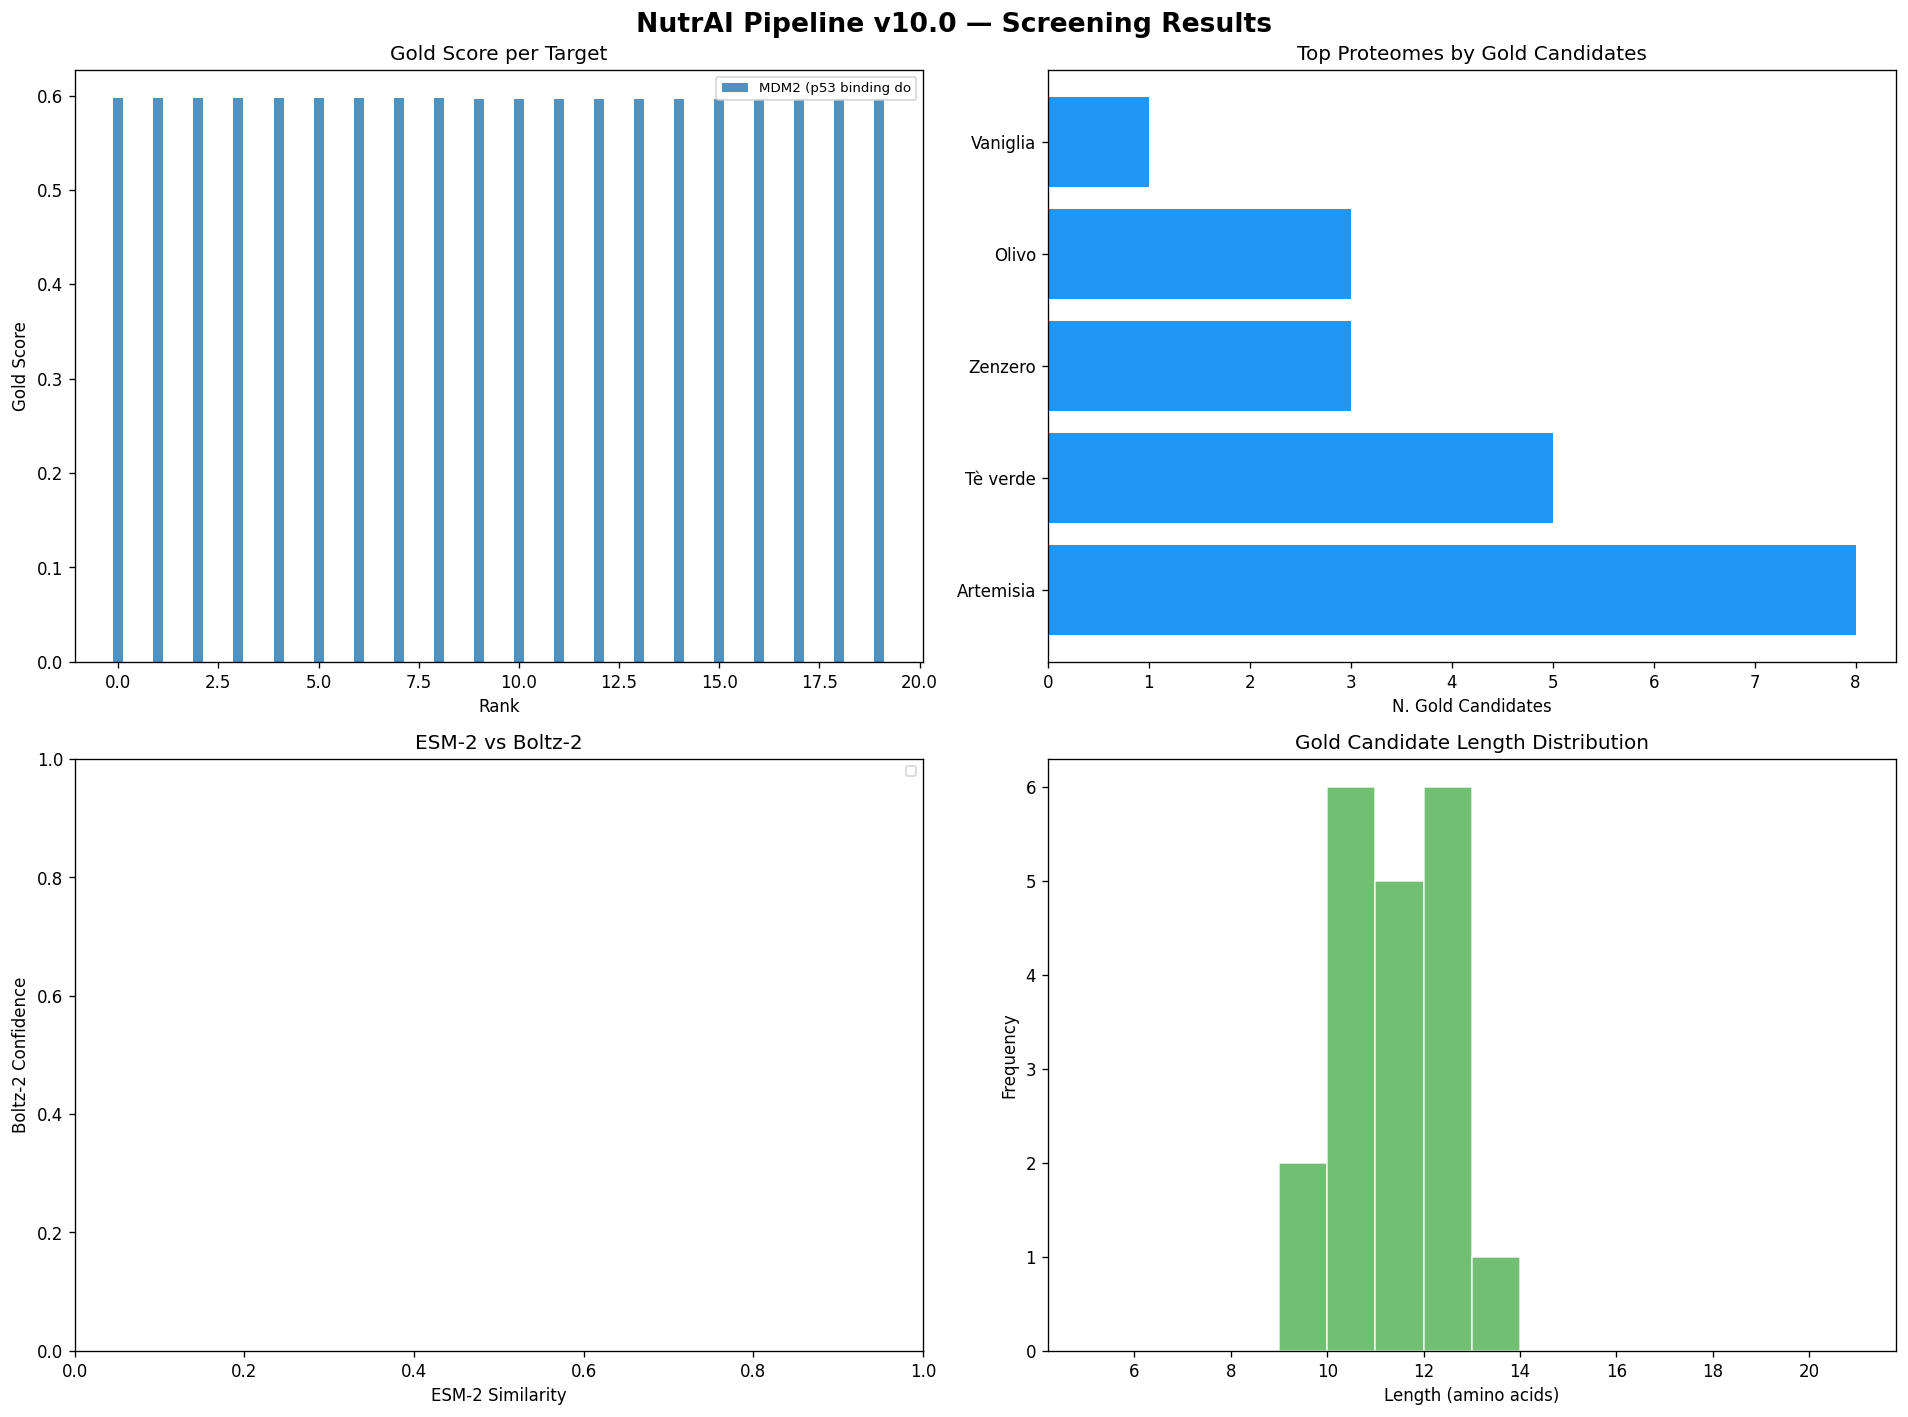


💾 Report saved: /workspace/nutrai_pipeline/results/report_overview.png


In [18]:
# ============================================================
# STEP 9 — VISUALIZATIONS AND REPORT
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["font.size"] = 10

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("NutrAI Pipeline v10.0 — Screening Results", fontsize=16, fontweight="bold")

# ── 1. Gold Score per Target ──
ax = axes[0, 0]
for i, target_name in enumerate(active_targets):
    tdata = active_targets[target_name]
    rows = conn.execute(
        "SELECT gold_score FROM gold_candidates WHERE target_name = ? ORDER BY gold_score DESC",
        (target_name,)
    ).fetchall()
    scores = [r[0] for r in rows]
    if scores:
        ax.bar([x + i*0.25 for x in range(len(scores))], scores, width=0.25,
               label=tdata["name"][:20], alpha=0.8)
ax.set_xlabel("Rank")
ax.set_ylabel("Gold Score")
ax.set_title("Gold Score per Target")
ax.legend(fontsize=8)

# ── 2. Distribution per Proteome ──
ax = axes[0, 1]
rows = conn.execute("""
    SELECT proteome, COUNT(*) as cnt
    FROM gold_candidates
    GROUP BY proteome
    ORDER BY cnt DESC
    LIMIT 10
""").fetchall()
if rows:
    names = [active_proteomes.get(r[0], {}).get("name", r[0])[:15] for r in rows]
    counts = [r[1] for r in rows]
    ax.barh(names, counts, color="#2196F3")
    ax.set_xlabel("N. Gold Candidates")
    ax.set_title("Top Proteomes by Gold Candidates")

# ── 3. ESM-2 Similarity vs Boltz-2 Confidence ──
ax = axes[1, 0]
for target_name in active_targets:
    rows = conn.execute("""
        SELECT esm2_similarity, boltz_confidence
        FROM gold_candidates
        WHERE target_name = ? AND boltz_confidence > 0
    """, (target_name,)).fetchall()
    if rows:
        x = [r[0] for r in rows]
        y = [r[1] for r in rows]
        ax.scatter(x, y, label=TARGETS[target_name]["name"][:20], alpha=0.7, s=50)
ax.set_xlabel("ESM-2 Similarity")
ax.set_ylabel("Boltz-2 Confidence")
ax.set_title("ESM-2 vs Boltz-2")
ax.legend(fontsize=8)

# ── 4. Gold peptide length distribution ──
ax = axes[1, 1]
rows = conn.execute("SELECT length FROM gold_candidates").fetchall()
if rows:
    lengths = [r[0] for r in rows]
    ax.hist(lengths, bins=range(5, 22), color="#4CAF50", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Length (amino acids)")
    ax.set_ylabel("Frequency")
    ax.set_title("Gold Candidate Length Distribution")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "report_overview.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"\n💾 Report saved: {os.path.join(RESULTS_DIR, 'report_overview.png')}")


In [19]:
from datetime import datetime
# ============================================================
# STEP 10 — FINAL EXPORT
# ============================================================

# ── Export Gold Candidates to CSV ──
gold_csv = os.path.join(RESULTS_DIR, "gold_candidates.csv")
rows = conn.execute("""
    SELECT peptide_seq, target_name, proteome, protein_id, enzyme, length,
           esm2_similarity, admet_score, boltz_confidence, boltz_iptm, boltz_plddt,
           final_rank, gold_score
    FROM gold_candidates
    ORDER BY target_name, gold_score DESC
""").fetchall()

with open(gold_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["peptide", "target", "proteome", "protein_id", "enzyme", "length",
                     "esm2_similarity", "admet_score", "boltz_confidence", "boltz_iptm",
                     "boltz_plddt", "rank", "gold_score"])
    writer.writerows(rows)

# ── Full export to JSON ──
gold_json = os.path.join(RESULTS_DIR, "gold_candidates.json")
all_gold = {}
for target_name in active_targets:
    rows = conn.execute("""
        SELECT * FROM gold_candidates WHERE target_name = ? ORDER BY gold_score DESC
    """, (target_name,)).fetchall()
    cols = [d[0] for d in conn.execute("SELECT * FROM gold_candidates LIMIT 0").description]
    all_gold[target_name] = [dict(zip(cols, r)) for r in rows]

with open(gold_json, "w") as f:
    json.dump(all_gold, f, indent=2)

# ── Final summary ──
print(f"{'='*60}")
print(f"🏆 NUTRAI PIPELINE v10.0 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"\n📦 Proteomes analyzed: {len(active_proteomes)}")
print(f"🧬 Total proteins: {sum(proteome_stats.values()):,}")
print(f"🧪 Peptides from hydrolysis: {total_peptides:,}")
print(f"🎯 Targets analyzed: {len(TARGETS)}")

for target_name in active_targets:
    tdata = active_targets[target_name]
    n_gold = conn.execute(
        "SELECT COUNT(*) FROM gold_candidates WHERE target_name = ?", (target_name,)
    ).fetchone()[0]
    best = conn.execute(
        "SELECT peptide_seq, gold_score FROM gold_candidates WHERE target_name = ? ORDER BY gold_score DESC LIMIT 1",
        (target_name,)
    ).fetchone()
    print(f"\n🎯 {tdata['name']}:")
    print(f"   Gold Candidates: {n_gold}")
    if best:
        print(f"   Best: {best[0]} (Gold Score: {best[1]:.4f})")

print(f"\n💾 Exported files:")
print(f"   📊 CSV: {gold_csv}")
print(f"   📋 JSON: {gold_json}")
print(f"   🗄️ SQLite: {DB_PATH}")
print(f"   📈 Report: {os.path.join(RESULTS_DIR, 'report_overview.png')}")

print(f"\n{'='*60}")
print(f"✅ PIPELINE COMPLETE!")
print(f"{'='*60}")

# Save su Drive/workspace
if SAVE_DIR:
    import shutil
    for f_name in [gold_csv, gold_json, DB_PATH]:
        if os.path.exists(f_name):
            shutil.copy2(f_name, SAVE_DIR)
    _tgt = "_".join(SELECTED_TARGETS)
    _db = "_".join(SELECTED_DBS)
    _date = datetime.now().strftime("%Y%m%d")
    _archive = os.path.join(SAVE_DIR, f"nutrai_{_tgt}_{_db}_{_date}.tar.gz")
    os.system(f'tar czf "{_archive}" -C {RESULTS_DIR} . 2>/dev/null')
    print(f"\n💾 Everything saved to: {SAVE_DIR}")

conn.close()


🏆 NUTRAI PIPELINE v10.0 — FINAL SUMMARY

📦 Proteomes analyzed: 22
🧬 Total proteins: 337,646
🧪 Peptides from hydrolysis: 8,645,509
🎯 Targets analyzed: 5

🎯 MDM2 (p53 binding domain):
   Gold Candidates: 20
   Best: EVLSDFESLLPK (Gold Score: 0.5972)

💾 Exported files:
   📊 CSV: /workspace/nutrai_pipeline/results/gold_candidates.csv
   📋 JSON: /workspace/nutrai_pipeline/results/gold_candidates.json
   🗄️ SQLite: /workspace/nutrai_pipeline/nutrai.db
   📈 Report: /workspace/nutrai_pipeline/results/report_overview.png

✅ PIPELINE COMPLETE!

💾 Everything saved to: /workspace/nutrai_results


## 🔍 STEP 10 — Database Query (optional)
Use this cell to query the database with custom SQL queries.


In [20]:
# ============================================================
# STEP 10 — QUERY DATABASE (modify the query as needed)
# ============================================================

# Reopen connection if closed
conn = sqlite3.connect(DB_PATH)

# ── Example 1: Top 10 absolute Gold ──
print("🏆 TOP 10 ABSOLUTE GOLD CANDIDATES:")
print(f"{'─'*90}")
rows = conn.execute("""
    SELECT peptide_seq, target_name, proteome, gold_score, esm2_similarity, boltz_confidence
    FROM gold_candidates
    ORDER BY gold_score DESC
    LIMIT 10
""").fetchall()
for i, r in enumerate(rows, 1):
    prot_name = active_proteomes.get(r[2], {}).get("name", r[2])
    print(f"  #{i:2d} {r[0]:20s} → {active_targets.get(r[1],{}).get('name','?'):25s} "
          f"[{prot_name:15s}] Gold={r[3]:.4f} ESM2={r[4]:.4f} Boltz={r[5]:.3f}")

# ── Example 2: Gold per proteome ──
print(f"\n📊 GOLD CANDIDATES PER PROTEOME:")
rows = conn.execute("""
    SELECT proteome, COUNT(*) as n, AVG(gold_score) as avg_score
    FROM gold_candidates
    GROUP BY proteome
    ORDER BY n DESC
""").fetchall()
for r in rows:
    prot_name = active_proteomes.get(r[0], {}).get("name", r[0])
    print(f"  {prot_name:25s} → {r[1]:3d} candidates (avg Gold={r[2]:.4f})")

# ── Example 3: Custom query (edit here!) ──
# CUSTOM_QUERY = "SELECT * FROM gold_candidates WHERE boltz_confidence > 0.8"
# pd.read_sql(CUSTOM_QUERY, conn)

conn.close()


🏆 TOP 10 ABSOLUTE GOLD CANDIDATES:
──────────────────────────────────────────────────────────────────────────────────────────
  # 1 EVLSDFESLLPK         → MDM2 (p53 binding domain) [Zenzero        ] Gold=0.5972 ESM2=0.9953 Boltz=0.000
  # 2 QLATSLDEFWK          → MDM2 (p53 binding domain) [Artemisia      ] Gold=0.5971 ESM2=0.9951 Boltz=0.000
  # 3 EILSDFESLLPK         → MDM2 (p53 binding domain) [Zenzero        ] Gold=0.5969 ESM2=0.9949 Boltz=0.000
  # 4 SFNELVSLWEK          → MDM2 (p53 binding domain) [Tè verde       ] Gold=0.5969 ESM2=0.9949 Boltz=0.000
  # 5 LPDLLKDSLENY         → MDM2 (p53 binding domain) [Olivo          ] Gold=0.5969 ESM2=0.9949 Boltz=0.000
  # 6 FDSFTELLNK           → MDM2 (p53 binding domain) [Artemisia      ] Gold=0.5969 ESM2=0.9948 Boltz=0.000
  # 7 LSVLNEFLPEDK         → MDM2 (p53 binding domain) [Artemisia      ] Gold=0.5969 ESM2=0.9948 Boltz=0.000
  # 8 HLPELLSDWK           → MDM2 (p53 binding domain) [Zenzero        ] Gold=0.5969 ESM2=0.9948 Boltz=0.000
  